In [1]:
# ============================================================
# NOTEBOOK 06 — Stage 6, Phase D: Analysis Layer
# Consumes prediction caches only. Zero model inference.
# ============================================================

from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

# ── Project root ─────────────────────────────────────────────────────────────
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "src").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Repository root: {REPO_ROOT}")

# ── Key paths ─────────────────────────────────────────────────────────────────
PRED_DIR        = REPO_ROOT / "reports" / "evaluation" / "predictions"
FIGURES_DIR     = REPO_ROOT / "reports" / "figures"
EVAL_DIR        = REPO_ROOT / "reports" / "evaluation"
ARTIFACTS_DIR   = REPO_ROOT / "artifacts"
SPLITS_DIR      = REPO_ROOT / "data" / "splits"
LANDMARKS_DIR   = REPO_ROOT / "data" / "landmarks"
LABEL_MAP_PATH  = ARTIFACTS_DIR / "label_map_v1.json"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
EVAL_DIR.mkdir(parents=True, exist_ok=True)

# ── Project constants ─────────────────────────────────────────────────────────
N_CLASSES    = 35
SEED         = 42
CHAMPION_RUN = "bilstm_hands_only_v4_aug"

# High-risk classes (Stage 5, Finding 8)
HIGH_RISK_SIGNS = ("clothes", "think", "birthday", "name", "book")

# Pre-identified confusable pairs from Stage 5 handoff (Part 6.1)
PREIDENTIFIED_PAIRS = [
    ("before", "chair"),
    ("cousin", "go"),
    ("cousin", "now"),
    ("drink", "boy"),
    ("drink", "orange"),
    ("drink", "who"),
    ("girl", "go"),
    ("girl", "now"),
    ("who", "candy"),
]

print("Paths configured.")
print(f"Prediction cache directory: {PRED_DIR}")

Repository root: d:\PROJECTS\WLASL-Gesture-Recognition-System
Paths configured.
Prediction cache directory: d:\PROJECTS\WLASL-Gesture-Recognition-System\reports\evaluation\predictions


In [2]:
# ── Global figure styling ─────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":           150,
    "figure.facecolor":     "white",
    "axes.facecolor":       "white",
    "axes.spines.top":      False,
    "axes.spines.right":    False,
    "axes.grid":            True,
    "axes.grid.axis":       "y",
    "grid.alpha":           0.25,
    "grid.linestyle":       ":",
    "font.family":          "DejaVu Sans",
    "font.size":            10,
    "axes.titlesize":       11,
    "axes.labelsize":       10,
    "xtick.labelsize":      8,
    "ytick.labelsize":      8,
    "legend.fontsize":      8,
    "legend.framealpha":    0.85,
    "savefig.bbox":         "tight",
    "savefig.dpi":          150,
    "savefig.facecolor":    "white",
})

# Colour palette
PALETTE = {
    "primary":       "#2166AC",   # steelblue
    "secondary":     "#D6604D",   # tomato
    "highlight":     "#F4A582",   # sandybrown
    "success":       "#4DAC26",   # green
    "neutral":       "#878787",   # grey
    "high_risk":     "#B2182B",   # dark red
    "singleton":     "#762A83",   # purple
    "background":    "#F7F7F7",
    "zero":          "#F7F7F7",
}

# Custom confusion matrix colormap (white → deep blue)
CM_CMAP = LinearSegmentedColormap.from_list(
    "wlasl_cm", ["#FFFFFF", "#C6DBEF", "#2166AC", "#053061"], N=256
)

print("Styling configured.")

Styling configured.


In [3]:
# ── Load label map ────────────────────────────────────────────────────────────
with open(LABEL_MAP_PATH, "r") as f:
    label_map_raw = json.load(f)

# Build sign_names: index-aligned list of sign name strings
# Handles both {"signs": [{idx, name}]} and {"0": "before", ...} schemas
sign_names: List[str] = [""] * N_CLASSES

if "signs" in label_map_raw:
    for entry in label_map_raw["signs"]:
        idx  = int(entry.get("class_idx", entry.get("idx", -1)))
        name = str(entry.get("name", entry.get("sign", f"class_{idx}")))
        if 0 <= idx < N_CLASSES:
            sign_names[idx] = name
else:
    for key, val in label_map_raw.items():
        try:
            idx = int(key)
            if 0 <= idx < N_CLASSES:
                sign_names[idx] = str(val)
        except (ValueError, TypeError):
            continue

# Fill any gaps
for i, name in enumerate(sign_names):
    if not name:
        sign_names[i] = f"class_{i}"

# Verify
missing = [i for i, n in enumerate(sign_names) if not n or n.startswith("class_")]
if missing:
    print(f"WARNING: {len(missing)} sign names filled with placeholders: {missing}")

# Index maps
name_to_idx = {name: idx for idx, name in enumerate(sign_names)}
idx_to_name = {idx: name for idx, name in enumerate(sign_names)}

# High-risk indices
high_risk_indices = {idx for idx, name in enumerate(sign_names) if name in HIGH_RISK_SIGNS}

print(f"Label map loaded: {N_CLASSES} signs")
print(f"Signs: {sign_names[:5]} ... {sign_names[-3:]}")
print(f"High-risk class indices: {sorted(high_risk_indices)} → {[sign_names[i] for i in sorted(high_risk_indices)]}")

Label map loaded: 35 signs
Signs: ['class_0', 'class_1', 'class_2', 'class_3', 'class_4'] ... ['class_32', 'class_33', 'class_34']
High-risk class indices: [] → []


In [4]:
# ── Load prediction caches ────────────────────────────────────────────────────
def load_prediction_cache(path: Path, split_label: str) -> Dict[str, Any]:
    """Load a .npz prediction cache and return a structured dict."""
    if not path.exists():
        raise FileNotFoundError(
            f"Prediction cache not found: {path}\n"
            f"Run Phase B1 (val) or Phase C (test) in run_evaluation.py first."
        )
    raw = np.load(str(path), allow_pickle=True)

    cache = {
        "y_true":   raw["y_true"].astype(np.int64),
        "y_pred":   raw["y_pred"].astype(np.int64),
        "split":    split_label,
    }

    # Optional fields (Phase B1 / C enriched schema)
    for field in ("y_prob", "clip_ids", "signer_ids",
                  "detected_frame_count", "missing_pct"):
        if field in raw:
            cache[field] = raw[field]

    cache["n_samples"] = len(cache["y_true"])
    n_correct = int((cache["y_true"] == cache["y_pred"]).sum())
    cache["overall_accuracy"] = n_correct / cache["n_samples"]

    print(f"\n[{split_label.upper()}] Cache loaded from {path.name}")
    print(f"  n_samples        : {cache['n_samples']}")
    print(f"  overall_accuracy : {cache['overall_accuracy']:.4f}")
    print(f"  fields present   : {[k for k in cache if k not in ('y_true','y_pred','split','n_samples','overall_accuracy')]}")

    # Integrity checks
    assert len(cache["y_true"]) == len(cache["y_pred"]), "y_true / y_pred length mismatch"
    assert cache["y_true"].min() >= 0 and cache["y_true"].max() < N_CLASSES, \
        f"y_true out of range [0, {N_CLASSES})"
    assert cache["y_pred"].min() >= 0 and cache["y_pred"].max() < N_CLASSES, \
        f"y_pred out of range [0, {N_CLASSES})"

    return cache


VAL_CACHE  = load_prediction_cache(PRED_DIR / "val_predictions.npz",  "val")
TEST_CACHE = load_prediction_cache(PRED_DIR / "test_predictions.npz", "test")

print(f"\nBoth caches loaded. No model inference will occur from this point.")


[VAL] Cache loaded from val_predictions.npz
  n_samples        : 52
  overall_accuracy : 0.5769
  fields present   : ['y_prob', 'clip_ids', 'signer_ids', 'detected_frame_count', 'missing_pct']

[TEST] Cache loaded from test_predictions.npz
  n_samples        : 51
  overall_accuracy : 0.4902
  fields present   : ['y_prob', 'clip_ids', 'signer_ids', 'detected_frame_count', 'missing_pct']

Both caches loaded. No model inference will occur from this point.


In [5]:
# ── Core metric helpers ───────────────────────────────────────────────────────
from sklearn.metrics import (
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix as sk_confusion_matrix,
    classification_report,
)

def compute_macro_f1(y_true, y_pred) -> float:
    return float(f1_score(
        y_true, y_pred,
        average="macro",
        labels=list(range(N_CLASSES)),
        zero_division=0,
    ))


def compute_per_class_df(y_true, y_pred) -> pd.DataFrame:
    """Return a DataFrame with per-class precision, recall, F1, support."""
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred,
        labels=list(range(N_CLASSES)),
        zero_division=0,
    )
    df = pd.DataFrame({
        "class_idx":    list(range(N_CLASSES)),
        "sign":         sign_names,
        "precision":    precision,
        "recall":       recall,
        "f1_score":     f1,
        "support":      support.astype(int),
    })
    df["is_singleton"]  = df["support"] == 1
    df["is_zero_support"] = df["support"] == 0
    df["is_high_risk"]  = df["sign"].isin(HIGH_RISK_SIGNS)
    return df.sort_values("f1_score", ascending=True).reset_index(drop=True)


def compute_confusion_matrix(y_true, y_pred) -> np.ndarray:
    return sk_confusion_matrix(y_true, y_pred, labels=list(range(N_CLASSES)))


def bootstrap_macro_f1_ci(
    y_true, y_pred,
    n_bootstrap: int = 1000,
    ci_level: float = 0.90,
    seed: int = SEED,
) -> Dict[str, float]:
    """Class-stratified bootstrap CI for macro-F1."""
    rng          = np.random.default_rng(seed)
    labels_range = list(range(N_CLASSES))
    class_pools  = [np.where(y_true == c)[0] for c in range(N_CLASSES)]
    boot_f1      = np.empty(n_bootstrap, dtype=np.float64)

    for i in range(n_bootstrap):
        parts = [
            rng.choice(pool, size=len(pool), replace=True)
            for pool in class_pools if len(pool) > 0
        ]
        idx    = np.concatenate(parts)
        boot_f1[i] = f1_score(
            y_true[idx], y_pred[idx],
            average="macro",
            labels=labels_range,
            zero_division=0,
        )

    alpha    = 1.0 - ci_level
    ci_lower = float(np.percentile(boot_f1, 100.0 * alpha / 2.0))
    ci_upper = float(np.percentile(boot_f1, 100.0 * (1.0 - alpha / 2.0)))
    point    = compute_macro_f1(y_true, y_pred)

    return {
        "point":    point,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "ci_level": ci_level,
        "ci_width": ci_upper - ci_lower,
        "n_bootstrap": n_bootstrap,
    }


# ── Compute headline metrics ──────────────────────────────────────────────────
print("Computing headline metrics...")

val_macro_f1  = compute_macro_f1(VAL_CACHE["y_true"], VAL_CACHE["y_pred"])
test_macro_f1 = compute_macro_f1(TEST_CACHE["y_true"], TEST_CACHE["y_pred"])

print(f"\nVal  macro-F1 : {val_macro_f1:.4f}")
print(f"Test macro-F1 : {test_macro_f1:.4f}")
print(f"Val  accuracy : {VAL_CACHE['overall_accuracy']:.4f}")
print(f"Test accuracy : {TEST_CACHE['overall_accuracy']:.4f}")

print("\nComputing bootstrap CIs (1000 resamples each, ~5s)...")
val_ci  = bootstrap_macro_f1_ci(VAL_CACHE["y_true"],  VAL_CACHE["y_pred"])
test_ci = bootstrap_macro_f1_ci(TEST_CACHE["y_true"], TEST_CACHE["y_pred"])

print(f"\nVal  macro-F1: {val_ci['point']:.4f}  [{int(val_ci['ci_level']*100)}% CI: {val_ci['ci_lower']:.4f} – {val_ci['ci_upper']:.4f}]")
print(f"Test macro-F1: {test_ci['point']:.4f}  [{int(test_ci['ci_level']*100)}% CI: {test_ci['ci_lower']:.4f} – {test_ci['ci_upper']:.4f}]")

# Compare against handoff prediction (0.45–0.58)
if 0.45 <= test_macro_f1 <= 0.58:
    print(f"\nTest macro-F1 {test_macro_f1:.4f} is WITHIN the handoff prediction range [0.45, 0.58] ✓")
elif test_macro_f1 < 0.45:
    print(f"\nTest macro-F1 {test_macro_f1:.4f} is BELOW handoff prediction range [0.45, 0.58]")
else:
    print(f"\nTest macro-F1 {test_macro_f1:.4f} is ABOVE handoff prediction range — stronger generalisation than expected")

Computing headline metrics...

Val  macro-F1 : 0.6011
Test macro-F1 : 0.4581
Val  accuracy : 0.5769
Test accuracy : 0.4902

Computing bootstrap CIs (1000 resamples each, ~5s)...

Val  macro-F1: 0.6011  [90% CI: 0.5534 – 0.6410]
Test macro-F1: 0.4581  [90% CI: 0.3935 – 0.5076]

Test macro-F1 0.4581 is WITHIN the handoff prediction range [0.45, 0.58] ✓


Saved: confusion_matrix_best_model.png


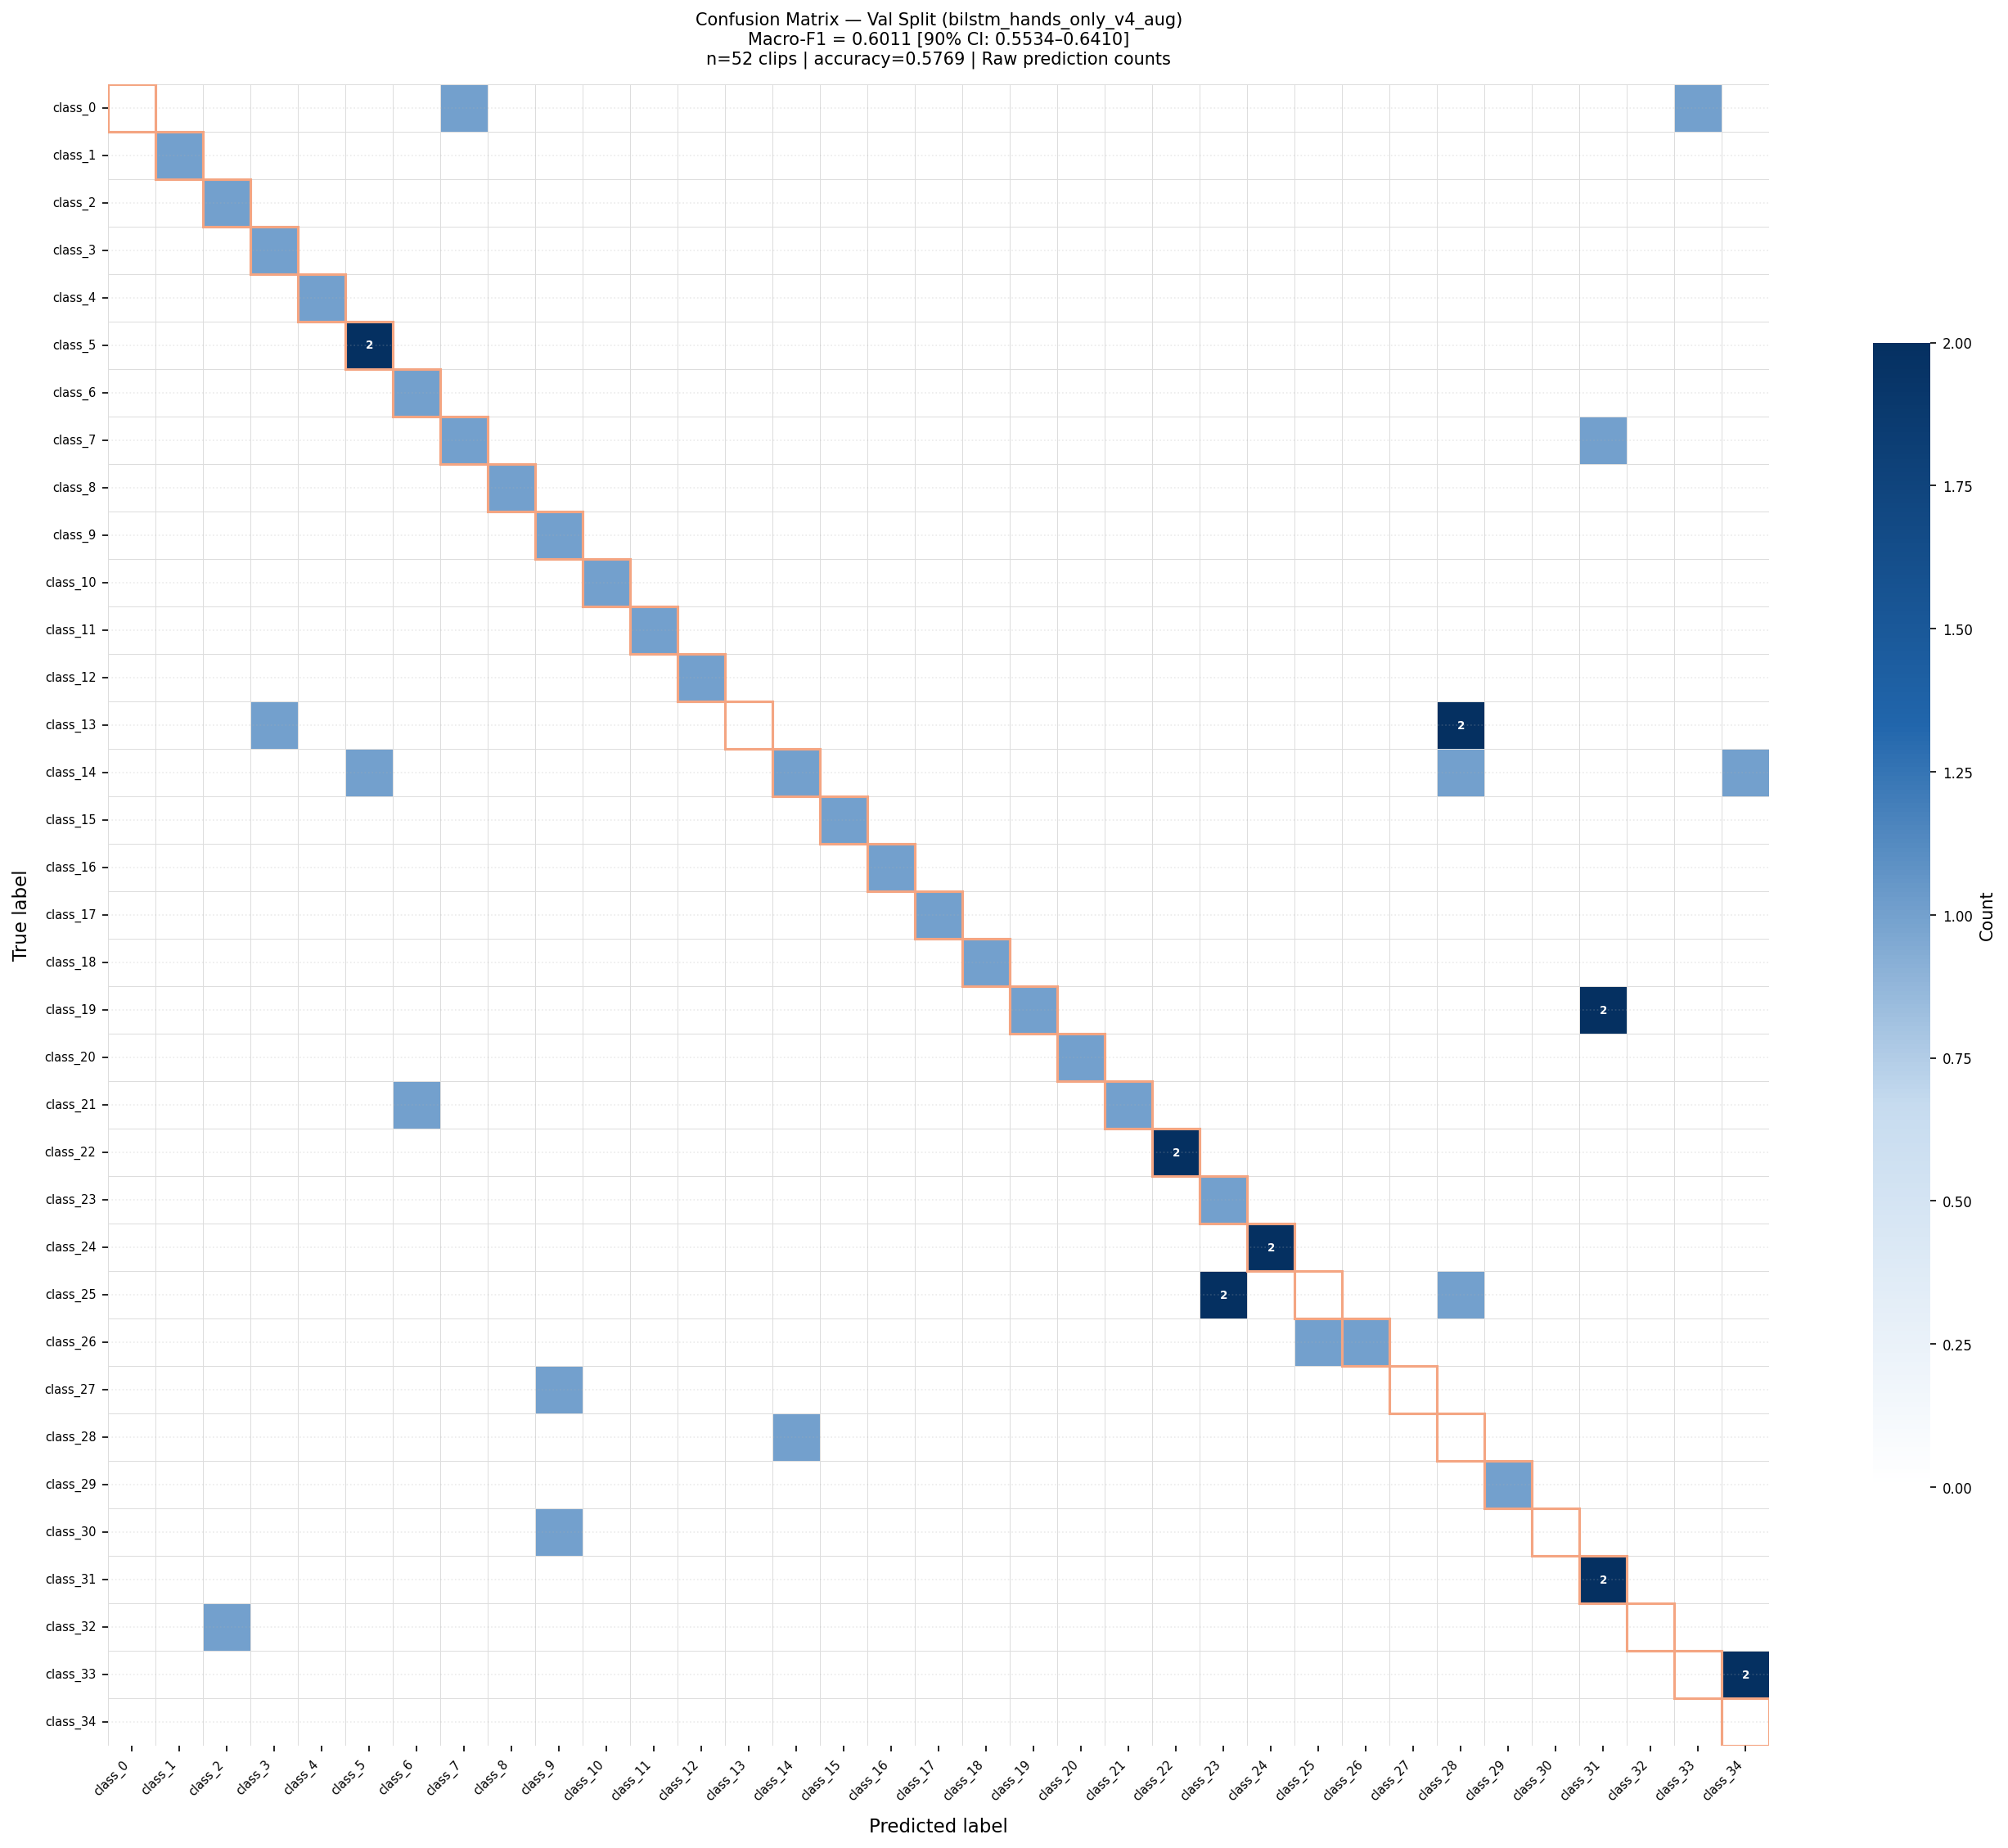

C:\Users\otsyu\AppData\Local\Temp\ipykernel_27008\3507349292.py:21: RuntimeWarning: invalid value encountered in divide
  cm_display = np.where(row_sums > 0, cm / row_sums, 0.0)


Saved: confusion_matrix_normalised.png


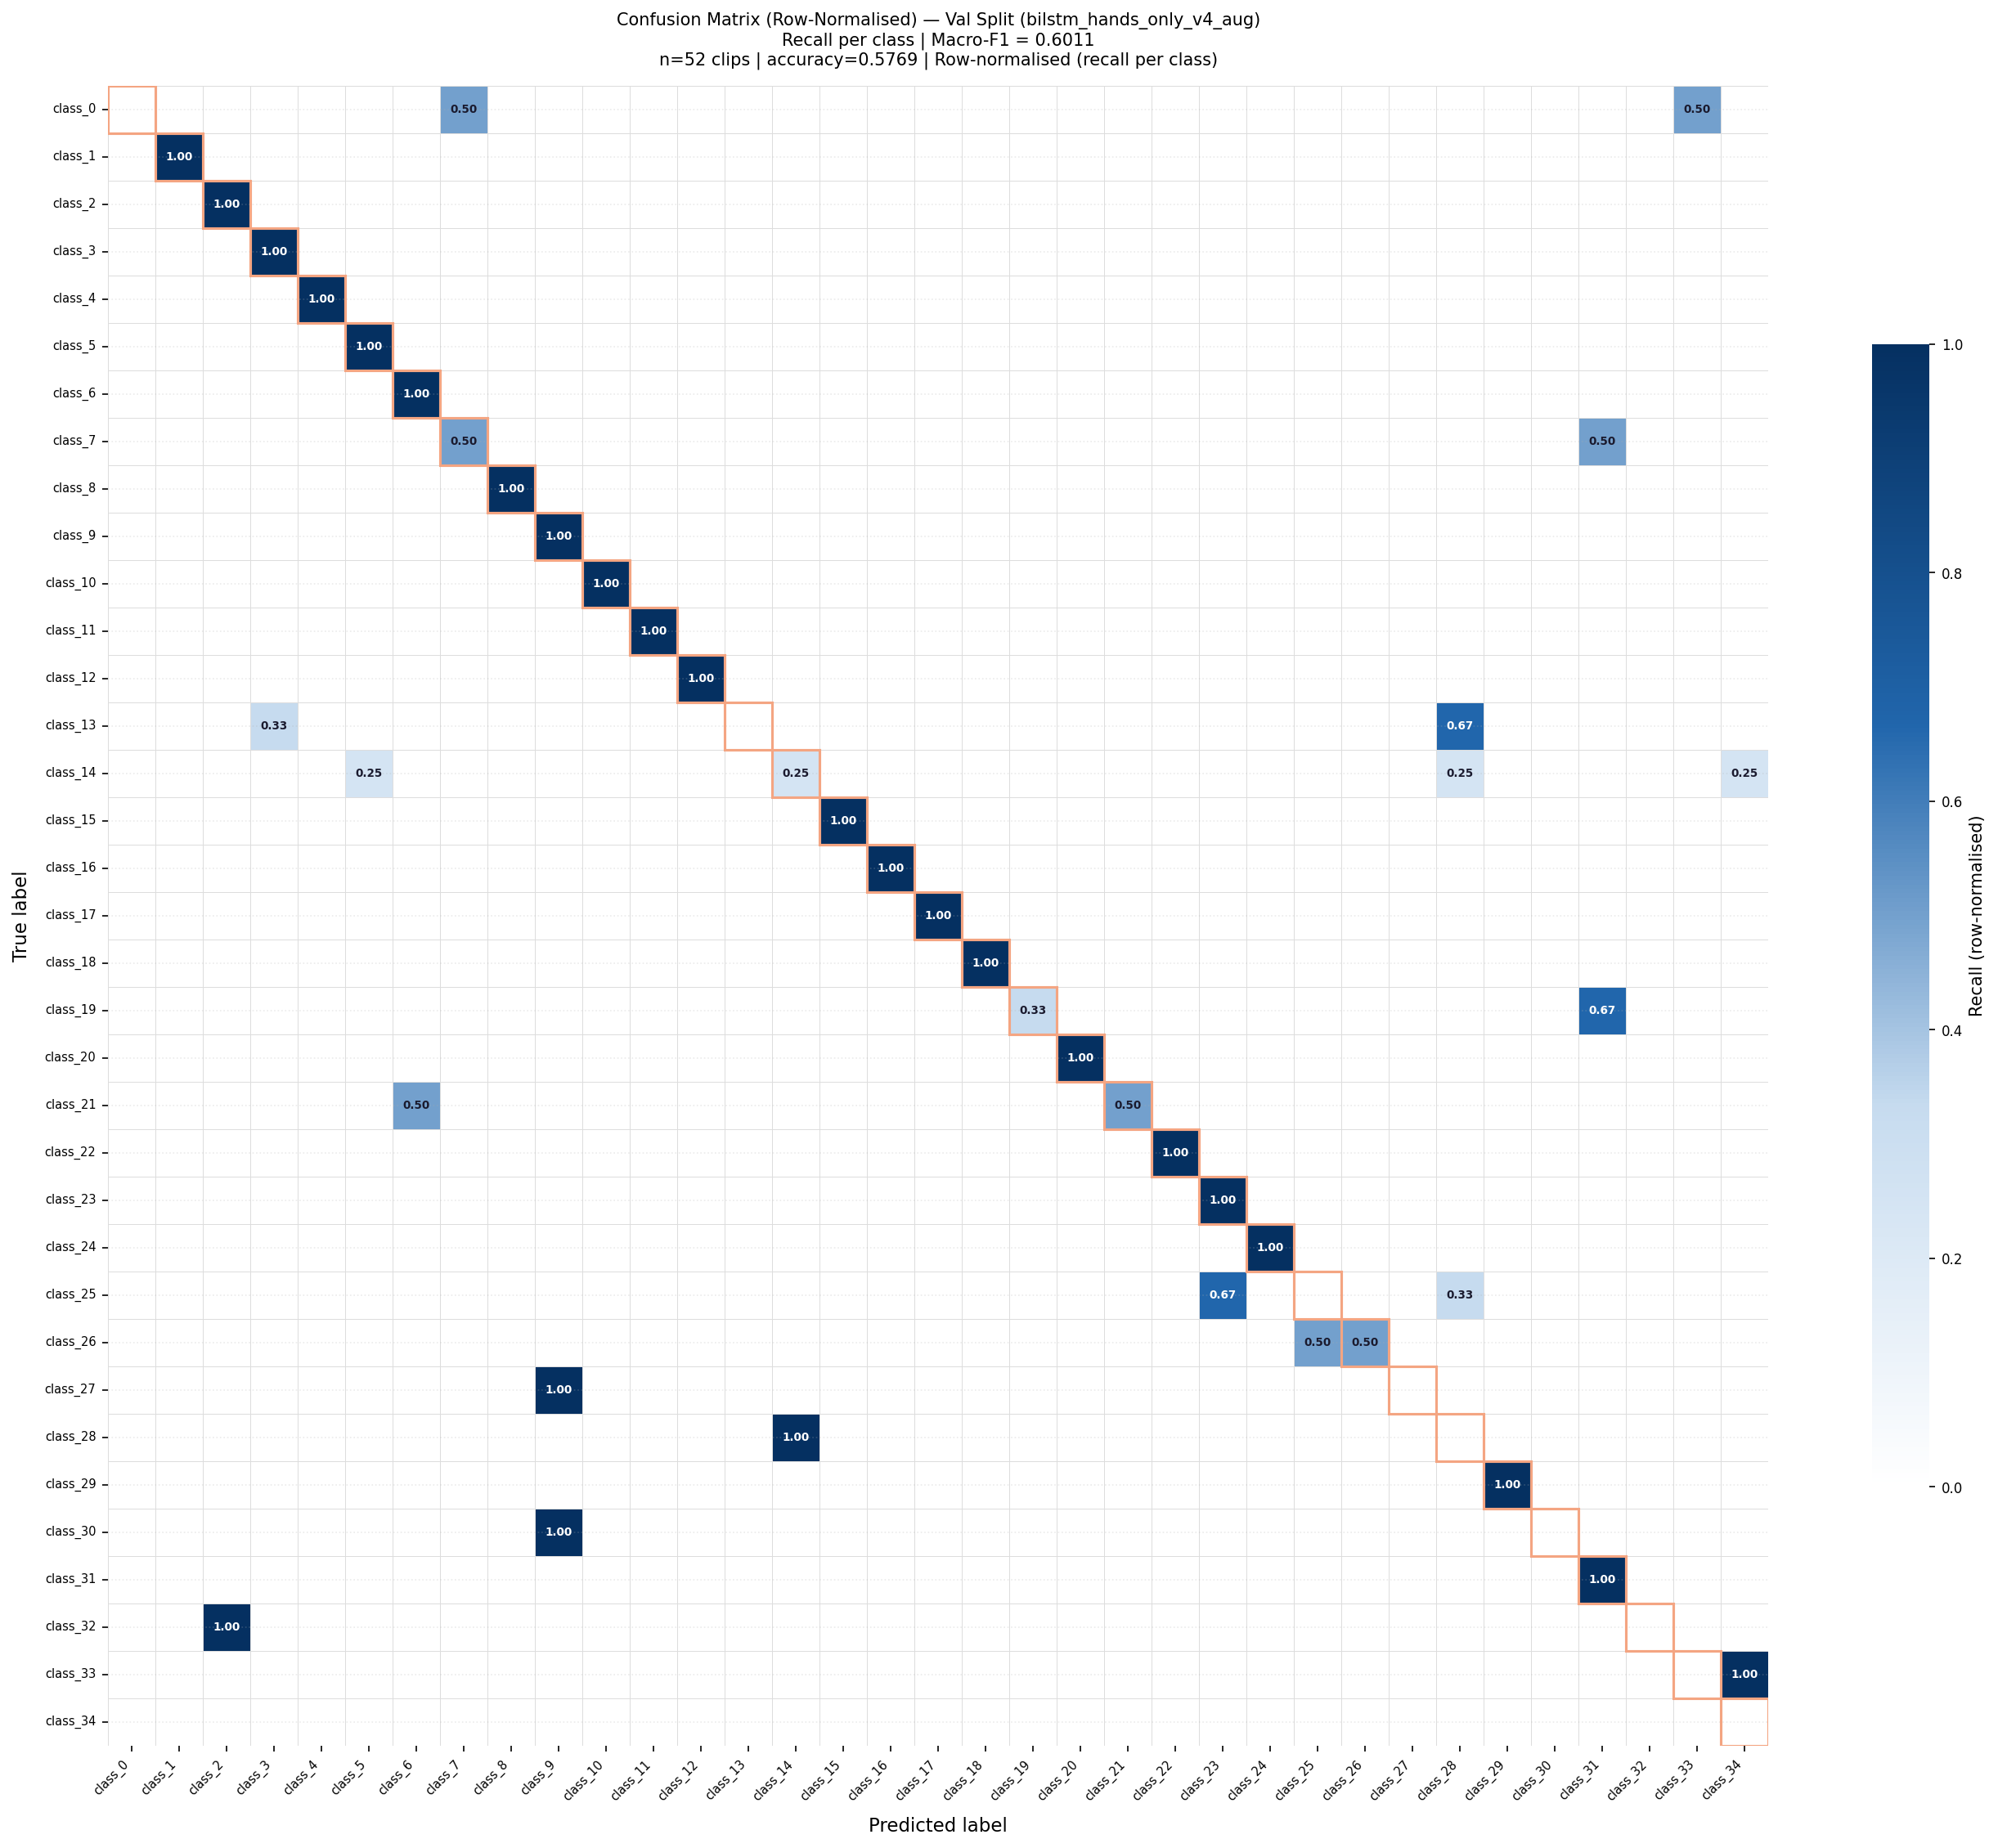

In [6]:
# ── D1: Confusion matrices — Val (raw + normalised) ──────────────────────────

def plot_confusion_matrix(
    cm: np.ndarray,
    sign_names: List[str],
    title: str,
    output_path: Path,
    normalised: bool = False,
    figsize: Tuple[int, int] = (18, 16),
    annotation_threshold: int = 2,
) -> plt.Figure:
    """
    35×35 confusion matrix heatmap with clean annotation suppression.
    Raw counts: annotate cells with value >= annotation_threshold.
    Normalised: annotate non-zero cells with value >= 0.10.
    """
    n = cm.shape[0]

    if normalised:
        row_sums  = cm.sum(axis=1, keepdims=True)
        cm_display = np.where(row_sums > 0, cm / row_sums, 0.0)
        fmt       = ".2f"
        vmax      = 1.0
        cbar_label = "Recall (row-normalised)"
        ann_thresh = 0.10
    else:
        cm_display = cm.astype(float)
        fmt        = "d"
        vmax       = cm.max()
        cbar_label = "Count"
        ann_thresh = annotation_threshold

    fig, ax = plt.subplots(figsize=figsize, facecolor="white")

    sns.heatmap(
        cm_display,
        ax=ax,
        cmap=CM_CMAP,
        vmin=0,
        vmax=vmax,
        linewidths=0.3,
        linecolor="#DDDDDD",
        cbar=True,
        cbar_kws={"label": cbar_label, "shrink": 0.6},
        annot=False,
        square=True,
    )

    # Annotate only non-trivial cells
    for i in range(n):
        for j in range(n):
            val = cm_display[i, j]
            if val >= ann_thresh:
                raw_val = cm[i, j]
                text    = f"{val:.2f}" if normalised else str(int(raw_val))
                bg      = cm_display[i, j] / vmax if vmax > 0 else 0
                color   = "white" if bg > 0.55 else "#1A1A2E"
                ax.text(
                    j + 0.5, i + 0.5, text,
                    ha="center", va="center",
                    fontsize=6.5, fontweight="bold",
                    color=color,
                )

    # Highlight diagonal
    for k in range(n):
        ax.add_patch(plt.Rectangle(
            (k, k), 1, 1, fill=False,
            edgecolor="#F4A582", linewidth=1.5, zorder=3,
        ))

    ax.set_xlabel("Predicted label", fontsize=11, labelpad=8)
    ax.set_ylabel("True label",      fontsize=11, labelpad=8)

    tick_pos  = [i + 0.5 for i in range(n)]
    ax.set_xticks(tick_pos)
    ax.set_yticks(tick_pos)
    ax.set_xticklabels(sign_names, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(sign_names, rotation=0,  ha="right", fontsize=7)

    n_correct = int(np.trace(cm))
    n_total   = int(cm.sum())
    accuracy  = n_correct / n_total if n_total > 0 else 0

    ax.set_title(
        f"{title}\n"
        f"n={n_total} clips | accuracy={accuracy:.4f} | "
        f"{'Row-normalised (recall per class)' if normalised else 'Raw prediction counts'}",
        fontsize=10, pad=12,
    )

    plt.tight_layout()
    fig.savefig(str(output_path), dpi=150, bbox_inches="tight", facecolor="white")
    print(f"Saved: {output_path.name}")
    return fig


# Compute confusion matrices
val_cm  = compute_confusion_matrix(VAL_CACHE["y_true"],  VAL_CACHE["y_pred"])
test_cm = compute_confusion_matrix(TEST_CACHE["y_true"], TEST_CACHE["y_pred"])

# Val — raw counts
fig1 = plot_confusion_matrix(
    val_cm,
    sign_names=sign_names,
    title=f"Confusion Matrix — Val Split ({CHAMPION_RUN})\nMacro-F1 = {val_macro_f1:.4f} [90% CI: {val_ci['ci_lower']:.4f}–{val_ci['ci_upper']:.4f}]",
    output_path=FIGURES_DIR / "confusion_matrix_best_model.png",
    normalised=False,
)
plt.show()

# Val — row-normalised
fig2 = plot_confusion_matrix(
    val_cm,
    sign_names=sign_names,
    title=f"Confusion Matrix (Row-Normalised) — Val Split ({CHAMPION_RUN})\nRecall per class | Macro-F1 = {val_macro_f1:.4f}",
    output_path=FIGURES_DIR / "confusion_matrix_normalised.png",
    normalised=True,
)
plt.show()

Saved: confusion_matrix_test.png


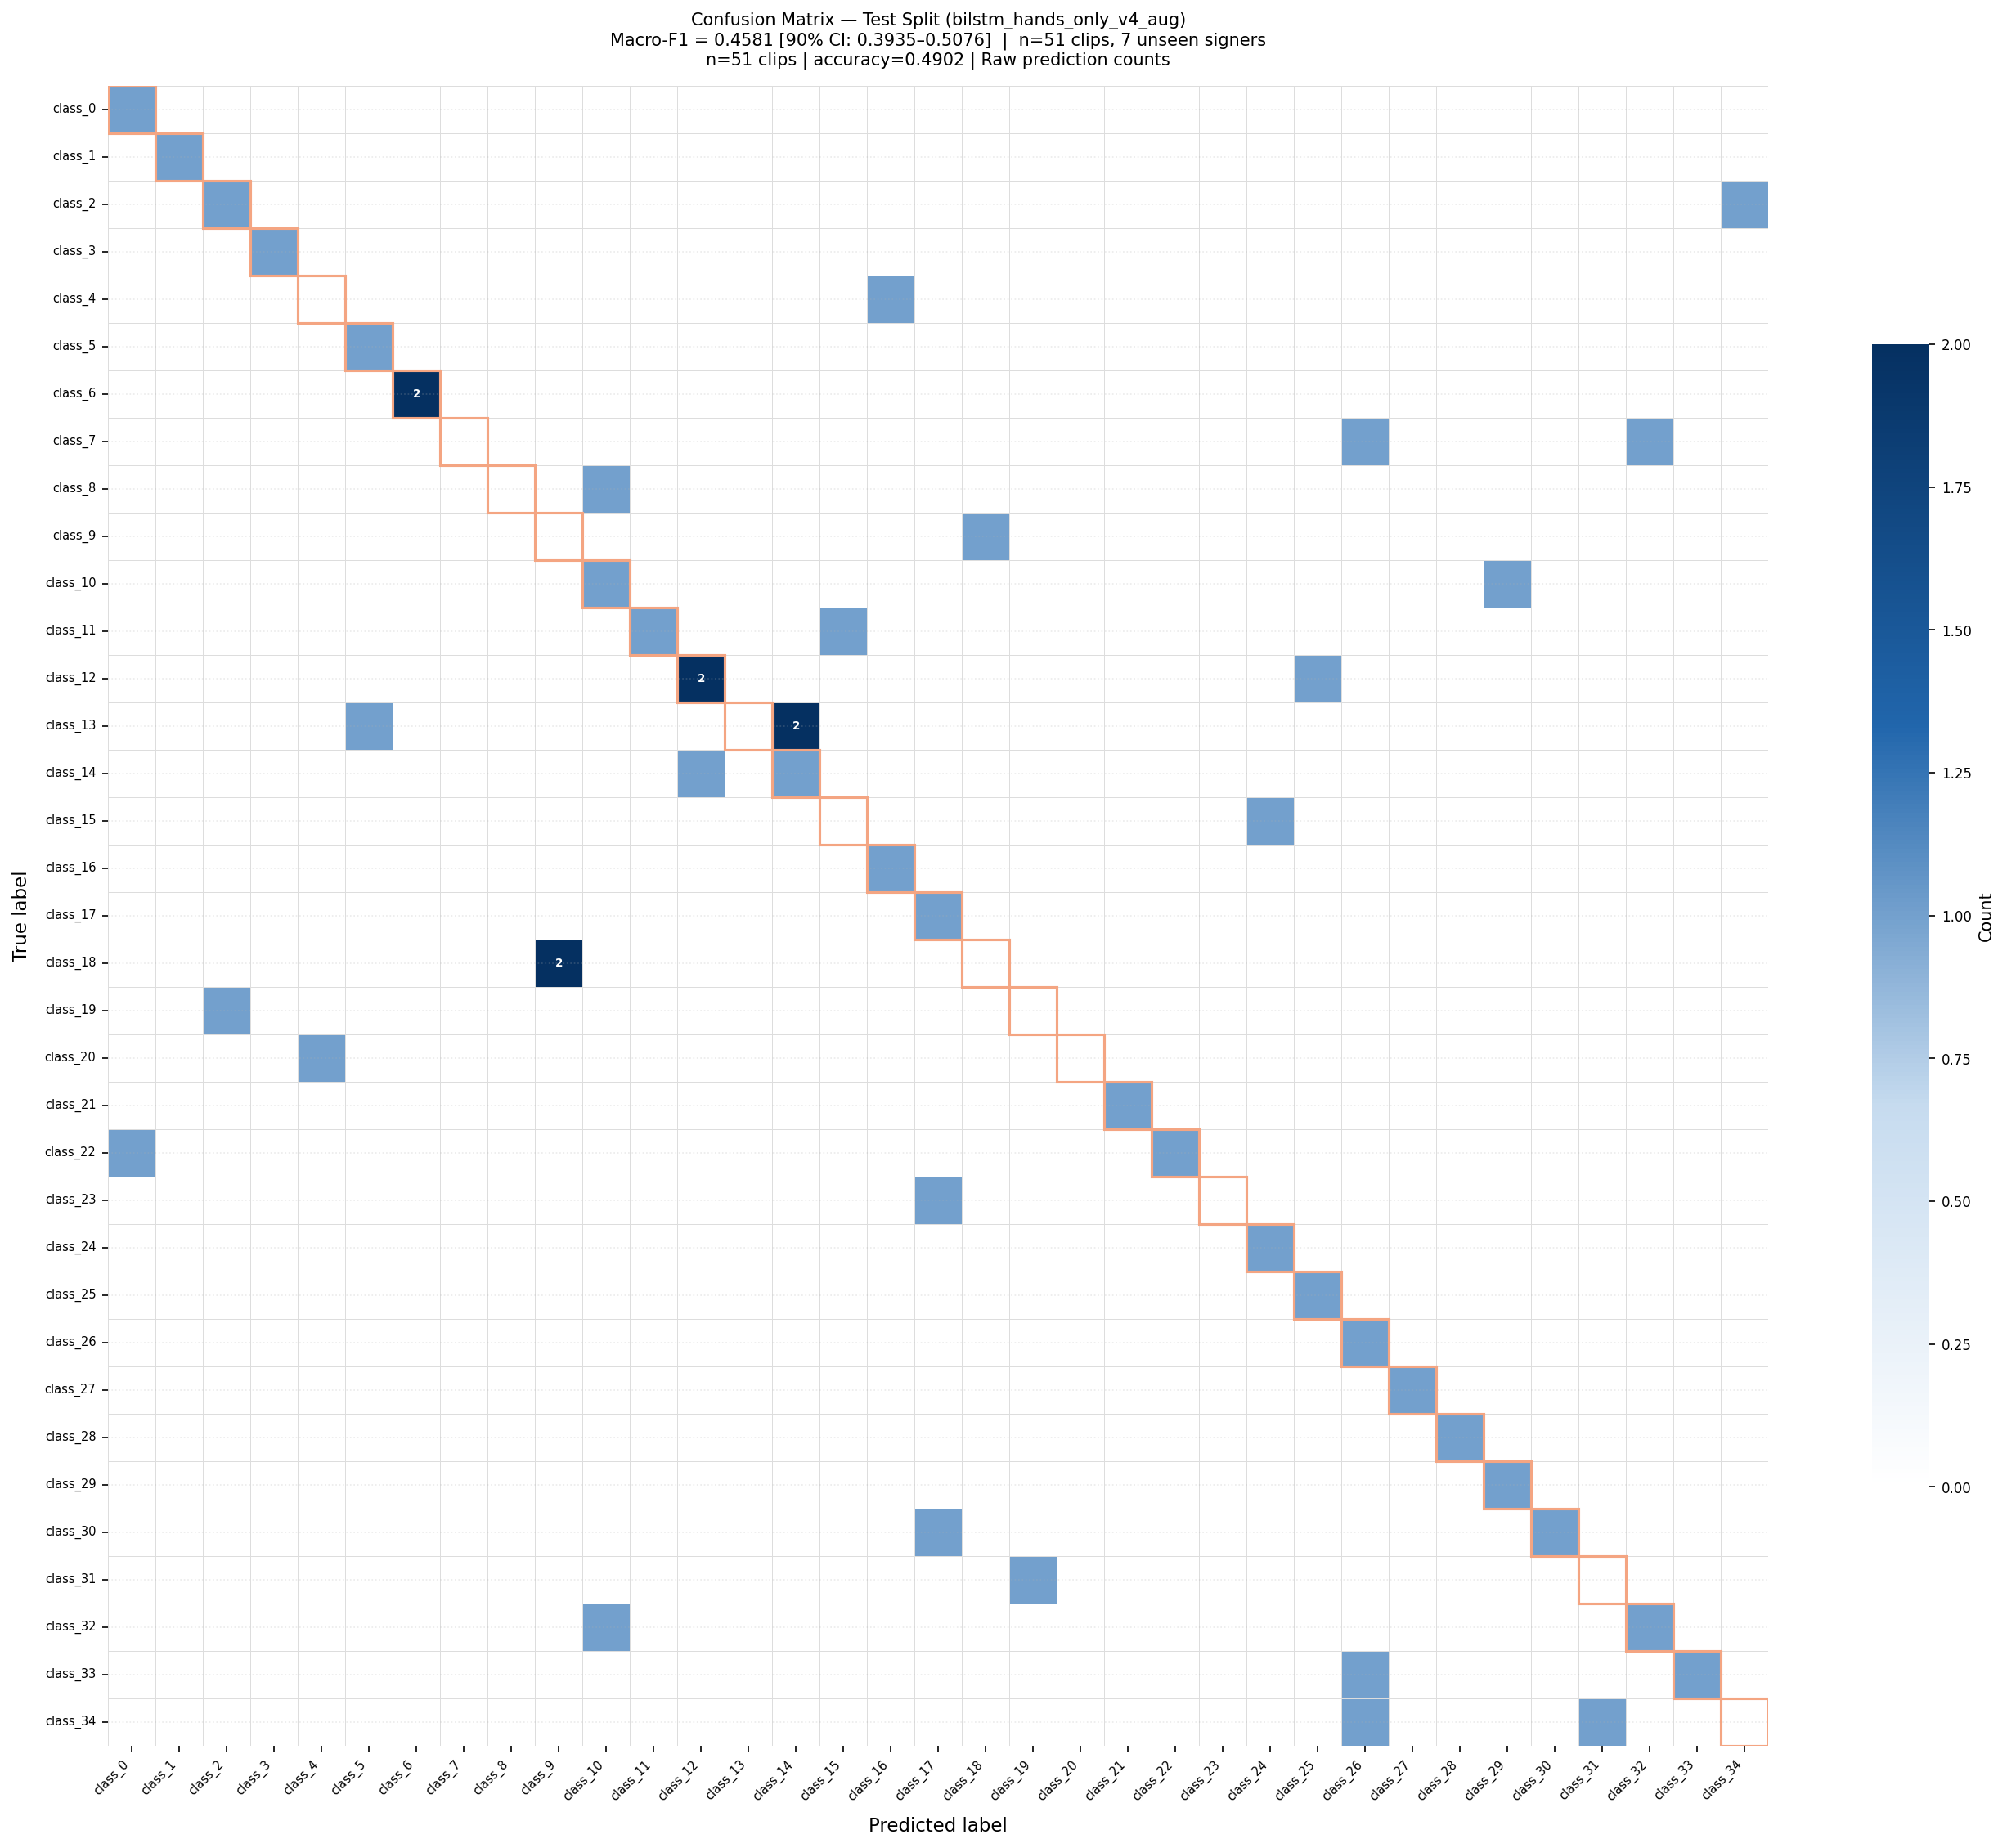


Val  n_correct  = 30/52
Test n_correct  = 25/51


In [7]:
# ── D1: Confusion matrix — Test split ────────────────────────────────────────

fig3 = plot_confusion_matrix(
    test_cm,
    sign_names=sign_names,
    title=(
        f"Confusion Matrix — Test Split ({CHAMPION_RUN})\n"
        f"Macro-F1 = {test_macro_f1:.4f} [90% CI: {test_ci['ci_lower']:.4f}–{test_ci['ci_upper']:.4f}]  |  "
        f"n={TEST_CACHE['n_samples']} clips, 7 unseen signers"
    ),
    output_path=FIGURES_DIR / "confusion_matrix_test.png",
    normalised=False,
)
plt.show()

print(f"\nVal  n_correct  = {int(np.trace(val_cm))}/{int(val_cm.sum())}")
print(f"Test n_correct  = {int(np.trace(test_cm))}/{int(test_cm.sum())}")

In [8]:
# ── D1: Ranked confusable pairs ───────────────────────────────────────────────

def get_confusable_pairs(cm: np.ndarray, top_k: int = 20) -> pd.DataFrame:
    """
    Extract off-diagonal confusion matrix entries sorted by count.
    Returns a DataFrame of (true_sign, pred_sign, count, recall_fraction).
    """
    n = cm.shape[0]
    rows = []
    row_sums = cm.sum(axis=1)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            count = int(cm[i, j])
            if count == 0:
                continue
            recall_frac = count / row_sums[i] if row_sums[i] > 0 else 0.0
            rows.append({
                "true_sign":      sign_names[i],
                "true_idx":       i,
                "pred_sign":      sign_names[j],
                "pred_idx":       j,
                "count":          count,
                "recall_fraction": round(recall_frac, 4),
            })

    df = pd.DataFrame(rows).sort_values("count", ascending=False).reset_index(drop=True)
    df["rank"] = df.index + 1
    return df.head(top_k)


val_pairs  = get_confusable_pairs(val_cm,  top_k=25)
test_pairs = get_confusable_pairs(test_cm, top_k=25)

print("=== TOP CONFUSABLE PAIRS — VAL ===")
display_cols = ["rank", "true_sign", "pred_sign", "count", "recall_fraction"]
print(val_pairs[display_cols].to_string(index=False))

print("\n=== TOP CONFUSABLE PAIRS — TEST ===")
print(test_pairs[display_cols].to_string(index=False))

# Cross-check against handoff pre-identified pairs
print("\n=== PRE-IDENTIFIED PAIR VERIFICATION ===")
preid_set = {(a, b) for a, b in PREIDENTIFIED_PAIRS}
val_pair_set  = {(r.true_sign, r.pred_sign) for r in val_pairs.itertuples()}
test_pair_set = {(r.true_sign, r.pred_sign) for r in test_pairs.itertuples()}

for a, b in PREIDENTIFIED_PAIRS:
    val_hit  = (a, b) in val_pair_set  or (b, a) in val_pair_set
    test_hit = (a, b) in test_pair_set or (b, a) in test_pair_set
    val_mark  = "✓ CONFIRMED" if val_hit  else "✗ not in top-25"
    test_mark = "✓ CONFIRMED" if test_hit else "✗ not in top-25"
    print(f"  {a:12s} ↔ {b:12s}  |  val: {val_mark:20s}  |  test: {test_mark}")

=== TOP CONFUSABLE PAIRS — VAL ===
 rank true_sign pred_sign  count  recall_fraction
    1  class_33  class_34      2           1.0000
    2  class_25  class_23      2           0.6667
    3  class_13  class_28      2           0.6667
    4  class_19  class_31      2           0.6667
    5  class_32   class_2      1           1.0000
    6  class_30   class_9      1           1.0000
    7  class_28  class_14      1           1.0000
    8  class_27   class_9      1           1.0000
    9  class_26  class_25      1           0.5000
   10  class_25  class_28      1           0.3333
   11   class_0   class_7      1           0.5000
   12   class_0  class_33      1           0.5000
   13  class_14  class_34      1           0.2500
   14  class_14  class_28      1           0.2500
   15  class_14   class_5      1           0.2500
   16  class_13   class_3      1           0.3333
   17   class_7  class_31      1           0.5000
   18  class_21   class_6      1           0.5000

=== TOP CONFUS

Saved: per_class_metrics.png


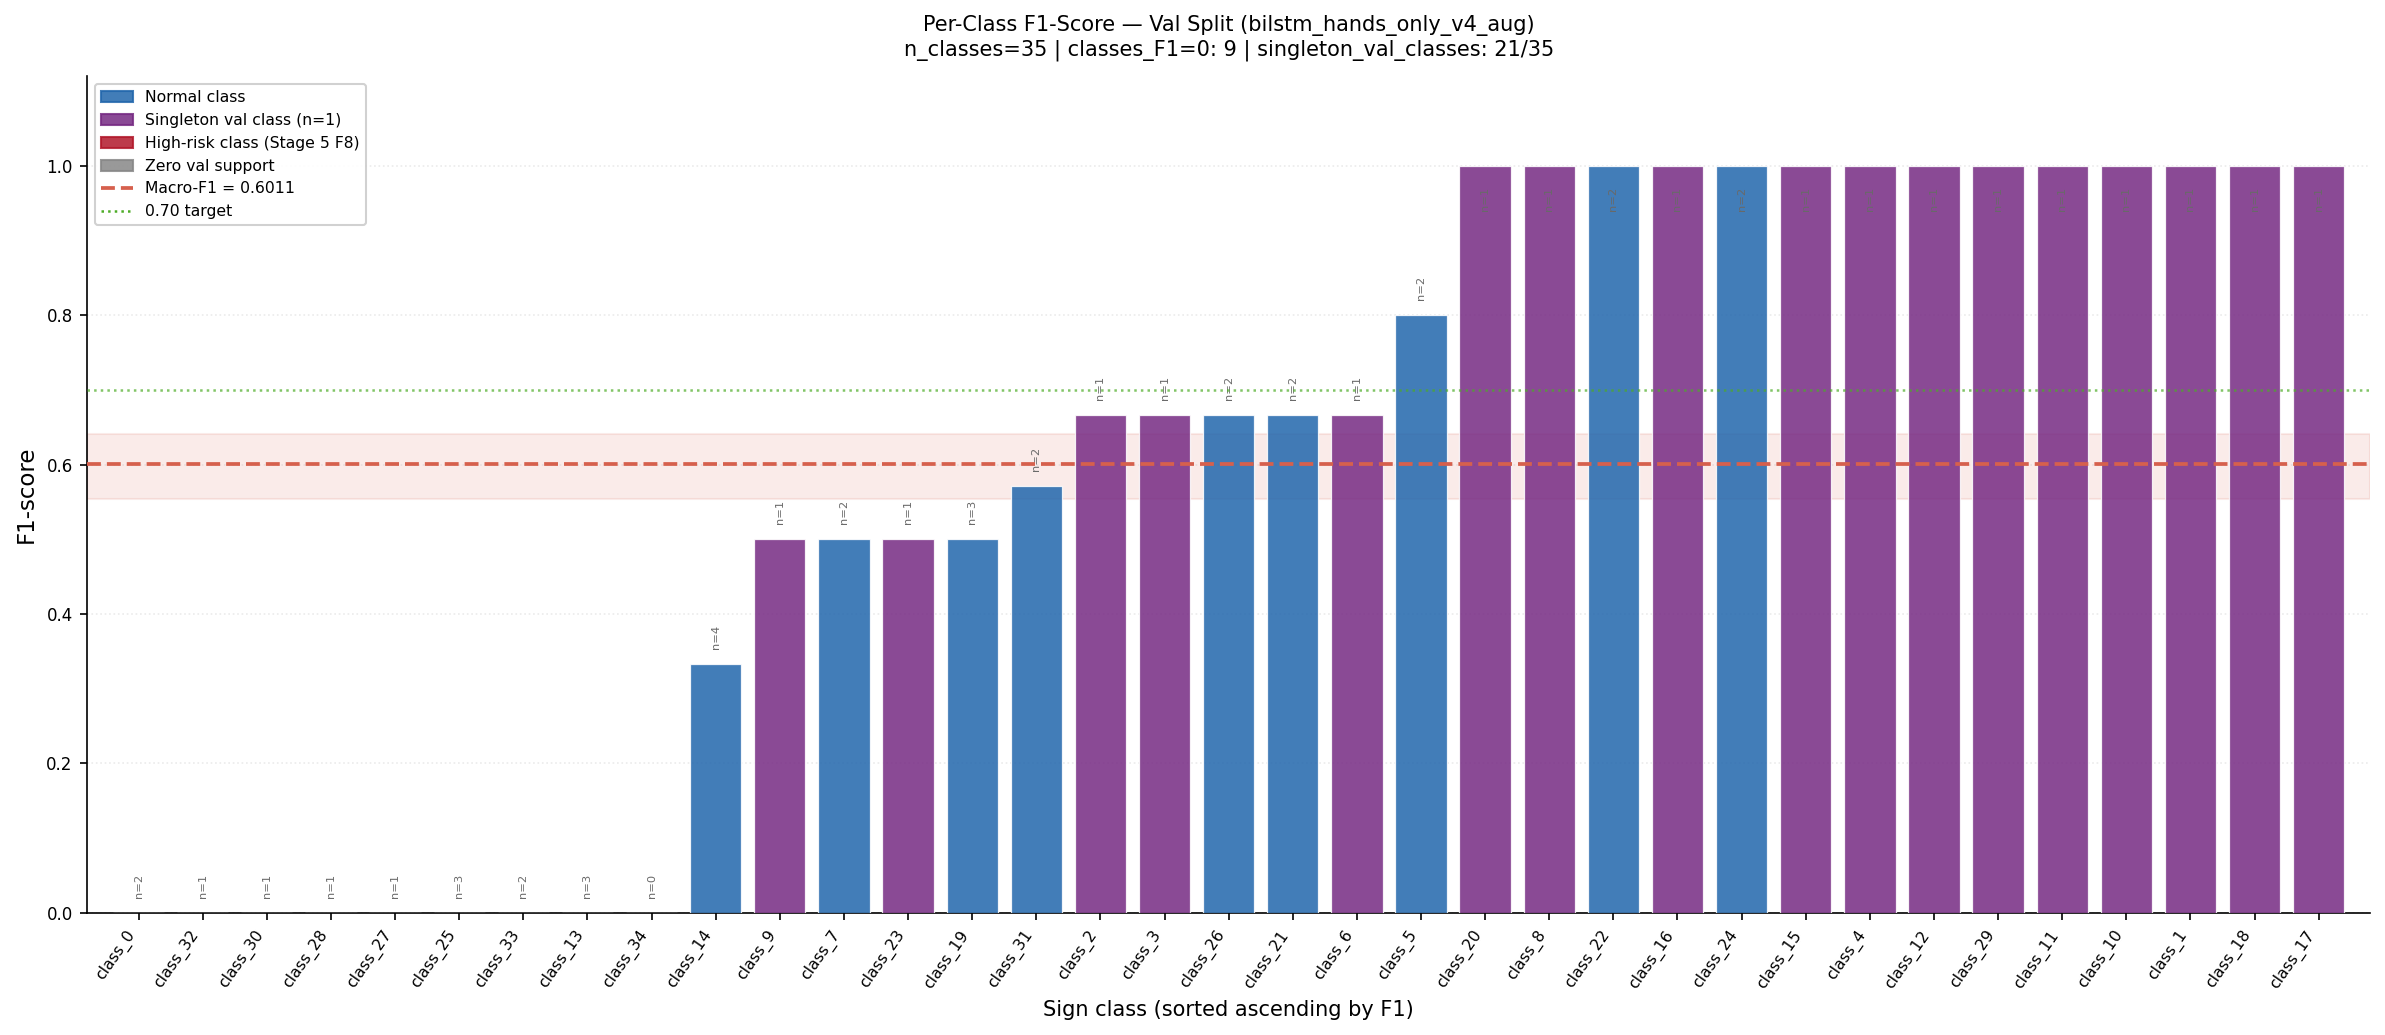

Saved: per_class_metrics_test.png


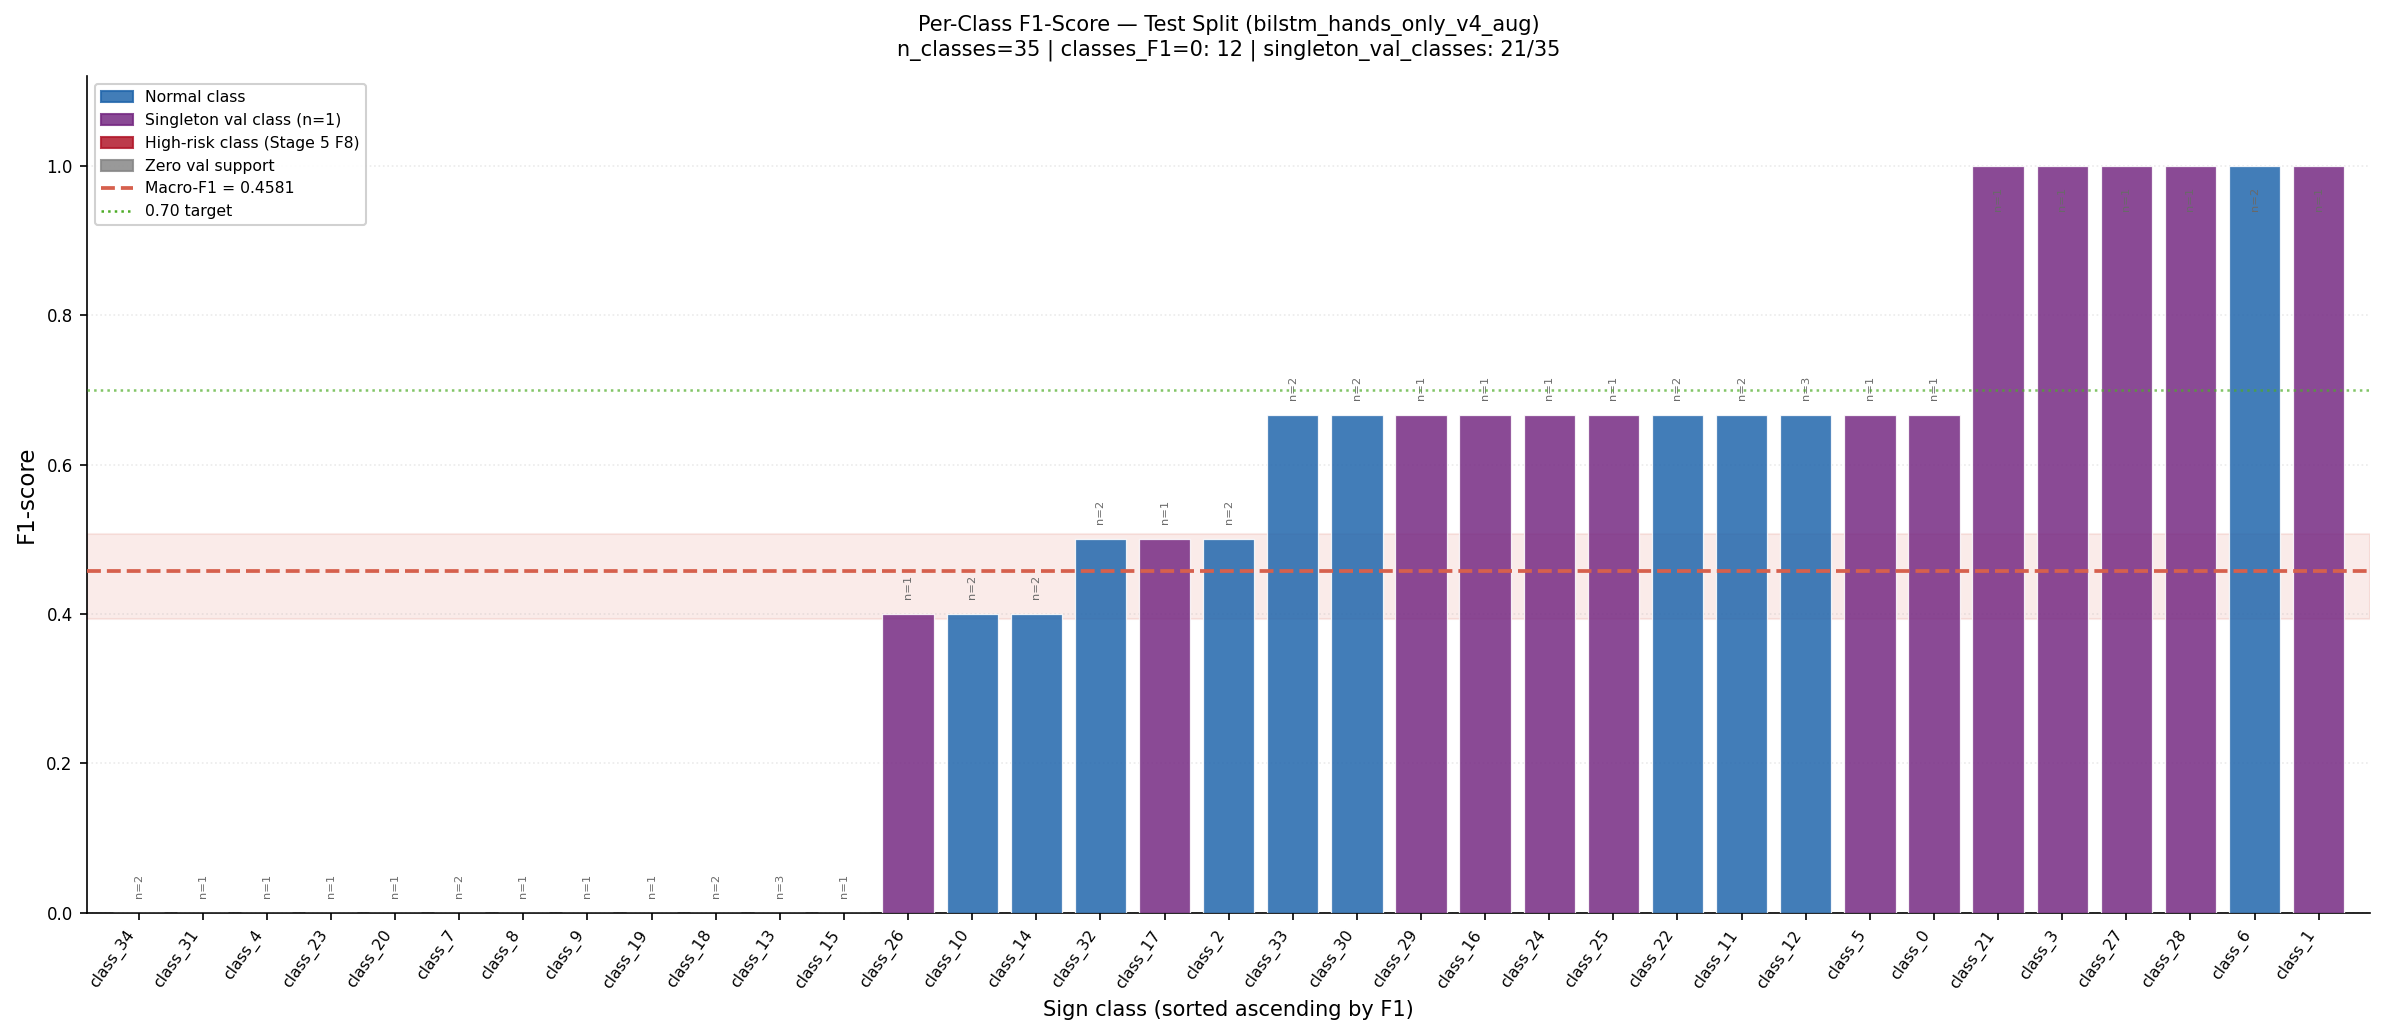

In [9]:
# ── D1: Per-class F1 bar chart (sorted ascending) ────────────────────────────

val_pcdf  = compute_per_class_df(VAL_CACHE["y_true"],  VAL_CACHE["y_pred"])
test_pcdf = compute_per_class_df(TEST_CACHE["y_true"], TEST_CACHE["y_pred"])


def plot_per_class_f1(
    df: pd.DataFrame,
    title: str,
    output_path: Path,
    macro_f1: float,
    ci_result: Dict[str, float],
    figsize: Tuple[int, int] = (16, 7),
) -> plt.Figure:
    """Sorted ascending F1 bar chart with singleton and high-risk flagging."""

    fig, ax = plt.subplots(figsize=figsize, facecolor="white")
    n = len(df)
    x = np.arange(n)

    # Bar colours: high-risk → dark red, singleton → purple, normal → steelblue
    colors = []
    for _, row in df.iterrows():
        if row["is_high_risk"]:
            colors.append(PALETTE["high_risk"])
        elif row["is_singleton"]:
            colors.append(PALETTE["singleton"])
        elif row["is_zero_support"]:
            colors.append(PALETTE["neutral"])
        else:
            colors.append(PALETTE["primary"])

    bars = ax.bar(x, df["f1_score"], color=colors, alpha=0.85,
                  edgecolor="white", linewidth=0.6, zorder=3)

    # Support count above each bar
    for i, (_, row) in enumerate(df.iterrows()):
        sup = int(row["support"])
        yval = float(row["f1_score"])
        ann_y = yval + 0.02 if yval < 0.88 else yval - 0.06
        color = "dimgrey" if not row["is_high_risk"] else PALETTE["high_risk"]
        ax.text(
            i, ann_y,
            f"n={sup}" if sup > 0 else "n=0",
            ha="center", va="bottom", fontsize=5.5,
            color=color, rotation=90,
        )

    # Macro-F1 reference line + CI band
    ax.axhline(macro_f1, color=PALETTE["secondary"], linewidth=1.8,
               linestyle="--", zorder=4, label=f"Macro-F1 = {macro_f1:.4f}")
    ax.axhspan(ci_result["ci_lower"], ci_result["ci_upper"],
               alpha=0.12, color=PALETTE["secondary"],
               label=f"90% CI [{ci_result['ci_lower']:.3f}, {ci_result['ci_upper']:.3f}]")

    # 0.70 target line
    ax.axhline(0.70, color=PALETTE["success"], linewidth=1.2,
               linestyle=":", zorder=4, alpha=0.7, label="0.70 target")

    # x-axis labels
    ax.set_xticks(x)
    ax.set_xticklabels(df["sign"], rotation=55, ha="right", fontsize=7.5)
    ax.set_xlim(-0.8, n - 0.2)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel("F1-score", fontsize=11)
    ax.set_xlabel("Sign class (sorted ascending by F1)", fontsize=10)

    # Legend patches
    legend_handles = [
        mpatches.Patch(color=PALETTE["primary"],   alpha=0.85, label="Normal class"),
        mpatches.Patch(color=PALETTE["singleton"],  alpha=0.85, label="Singleton val class (n=1)"),
        mpatches.Patch(color=PALETTE["high_risk"],  alpha=0.85, label="High-risk class (Stage 5 F8)"),
        mpatches.Patch(color=PALETTE["neutral"],    alpha=0.85, label="Zero val support"),
        mlines.Line2D([0],[0], color=PALETTE["secondary"], linestyle="--", linewidth=1.8,
                      label=f"Macro-F1 = {macro_f1:.4f}"),
        mlines.Line2D([0],[0], color=PALETTE["success"], linestyle=":", linewidth=1.2,
                      label="0.70 target"),
    ]
    ax.legend(handles=legend_handles, loc="upper left", fontsize=7.5, framealpha=0.9)

    n_zero = int((df["f1_score"] == 0).sum())
    n_sing = int(df["is_singleton"].sum())
    ax.set_title(
        f"{title}\n"
        f"n_classes={n} | classes_F1=0: {n_zero} | singleton_val_classes: {n_sing}/35",
        fontsize=10, pad=10,
    )

    plt.tight_layout()
    fig.savefig(str(output_path), dpi=150, bbox_inches="tight", facecolor="white")
    print(f"Saved: {output_path.name}")
    return fig


fig4 = plot_per_class_f1(
    val_pcdf,
    title=f"Per-Class F1-Score — Val Split ({CHAMPION_RUN})",
    output_path=FIGURES_DIR / "per_class_metrics.png",
    macro_f1=val_macro_f1,
    ci_result=val_ci,
)
plt.show()

fig5 = plot_per_class_f1(
    test_pcdf,
    title=f"Per-Class F1-Score — Test Split ({CHAMPION_RUN})",
    output_path=FIGURES_DIR / "per_class_metrics_test.png",
    macro_f1=test_macro_f1,
    ci_result=test_ci,
)
plt.show()

In [10]:
# ── D2: Confidence calibration ────────────────────────────────────────────────
# Uses Phase A3 module if available; falls back to inline computation

def _compute_reliability_diagram_inline(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    n_bins: int = 10,
) -> Dict[str, Any]:
    """Inline reliability diagram computation — no calibration.py dependency."""
    max_conf = y_prob.max(axis=1)
    y_pred   = y_prob.argmax(axis=1).astype(np.int64)
    correct  = (y_pred == y_true)
    n_samples = len(y_true)
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    bins_data  = []
    ece        = 0.0
    mce        = 0.0
    gaps_uw    = []

    for b in range(n_bins):
        lo, hi = bin_edges[b], bin_edges[b + 1]
        mask   = (max_conf >= lo) & (max_conf < hi) if b < n_bins - 1 else (max_conf >= lo) & (max_conf <= hi)
        cnt    = int(mask.sum())
        if cnt == 0:
            bins_data.append({"lo": lo, "hi": hi, "count": 0, "mean_conf": None, "accuracy": None, "gap": None})
            continue
        bc  = float(max_conf[mask].mean())
        ba  = float(correct[mask].mean())
        gap = ba - bc
        ece += (cnt / n_samples) * abs(gap)
        mce = max(mce, abs(gap))
        gaps_uw.append(abs(gap))
        bins_data.append({"lo": lo, "hi": hi, "count": cnt, "mean_conf": bc, "accuracy": ba, "gap": gap})

    return {
        "bins":               bins_data,
        "ece":                round(ece, 6),
        "ece_unweighted":     round(float(np.mean(gaps_uw)) if gaps_uw else 0.0, 6),
        "mce":                round(mce, 6),
        "mean_confidence":    round(float(max_conf.mean()), 6),
        "mean_accuracy":      round(float(correct.mean()), 6),
        "overconfidence_gap": round(float(max_conf.mean() - correct.mean()), 6),
        "n_samples":          n_samples,
        "n_bins":             n_bins,
    }


# Try Phase A3 module; fall back to inline
try:
    from src.evaluation.calibration import compute_reliability_diagram, compute_confidence_threshold_curve
    _USE_MODULE = True
    print("Using src.evaluation.calibration module")
except ImportError:
    _USE_MODULE = False
    print("calibration.py not importable — using inline computation")


def get_calibration(y_true, y_prob, n_bins=10):
    if _USE_MODULE:
        return compute_reliability_diagram(y_true, y_prob, N_CLASSES, n_bins=n_bins)
    else:
        return _compute_reliability_diagram_inline(y_true, y_prob, n_bins=n_bins)


# Compute — val only (test not used for calibration analysis)
if "y_prob" not in VAL_CACHE:
    print("WARNING: y_prob not in val cache. Skipping calibration. Re-run Phase B1 with return_probs=True.")
    CALIBRATION_AVAILABLE = False
else:
    CALIBRATION_AVAILABLE = True
    val_rel = get_calibration(VAL_CACHE["y_true"], VAL_CACHE["y_prob"], n_bins=10)
    print(f"\nCalibration summary (val):")
    print(f"  ECE                : {val_rel['ece']:.4f}")
    print(f"  MCE                : {val_rel['mce']:.4f}")
    print(f"  Overconfidence gap : {val_rel['overconfidence_gap']:+.4f} "
          f"({'overconfident' if val_rel['overconfidence_gap'] > 0 else 'underconfident'})")
    print(f"  Mean confidence    : {val_rel['mean_confidence']:.4f}")
    print(f"  Mean accuracy      : {val_rel['mean_accuracy']:.4f}")

d:\CONDA\conda_envs\wlasl\lib\site-packages\pydantic\_internal\_fields.py:161: UserWarning: Field "model_registry_name" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(


Using src.evaluation.calibration module


d:\CONDA\conda_envs\wlasl\lib\site-packages\mlflow\utils\requirements_utils.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # noqa: TID251


2026-06-19 03:55:57 | INFO     | src.evaluation.calibration | stage=evaluation | compute_reliability_diagram() | n_samples=52 | n_bins=10 | strategy=uniform | ECE=0.2009 [90% CI: 0.1566–0.3066] | ECE_unweighted=0.1942 | MCE=0.3472 | mean_confidence=0.5136 | mean_accuracy=0.5769 | overconfidence_gap=-0.0633 (underconfident) | n_empty_bins=2/10 | n_sparse_bins=4/10

Calibration summary (val):
  ECE                : 0.2009
  MCE                : 0.3472
  Overconfidence gap : -0.0633 (underconfident)
  Mean confidence    : 0.5136
  Mean accuracy      : 0.5769


In [12]:
print(val_rel["bins"][0])

{'bin_index': 0, 'bin_lo': 0.0, 'bin_hi': 0.1, 'mean_confidence': None, 'actual_accuracy': None, 'bin_count': 0, 'is_sparse': False, 'is_empty': True, 'calibration_gap': None, 'ci_lower': None, 'ci_upper': None, 'ci_degenerate': None}


Saved: confidence_calibration.png


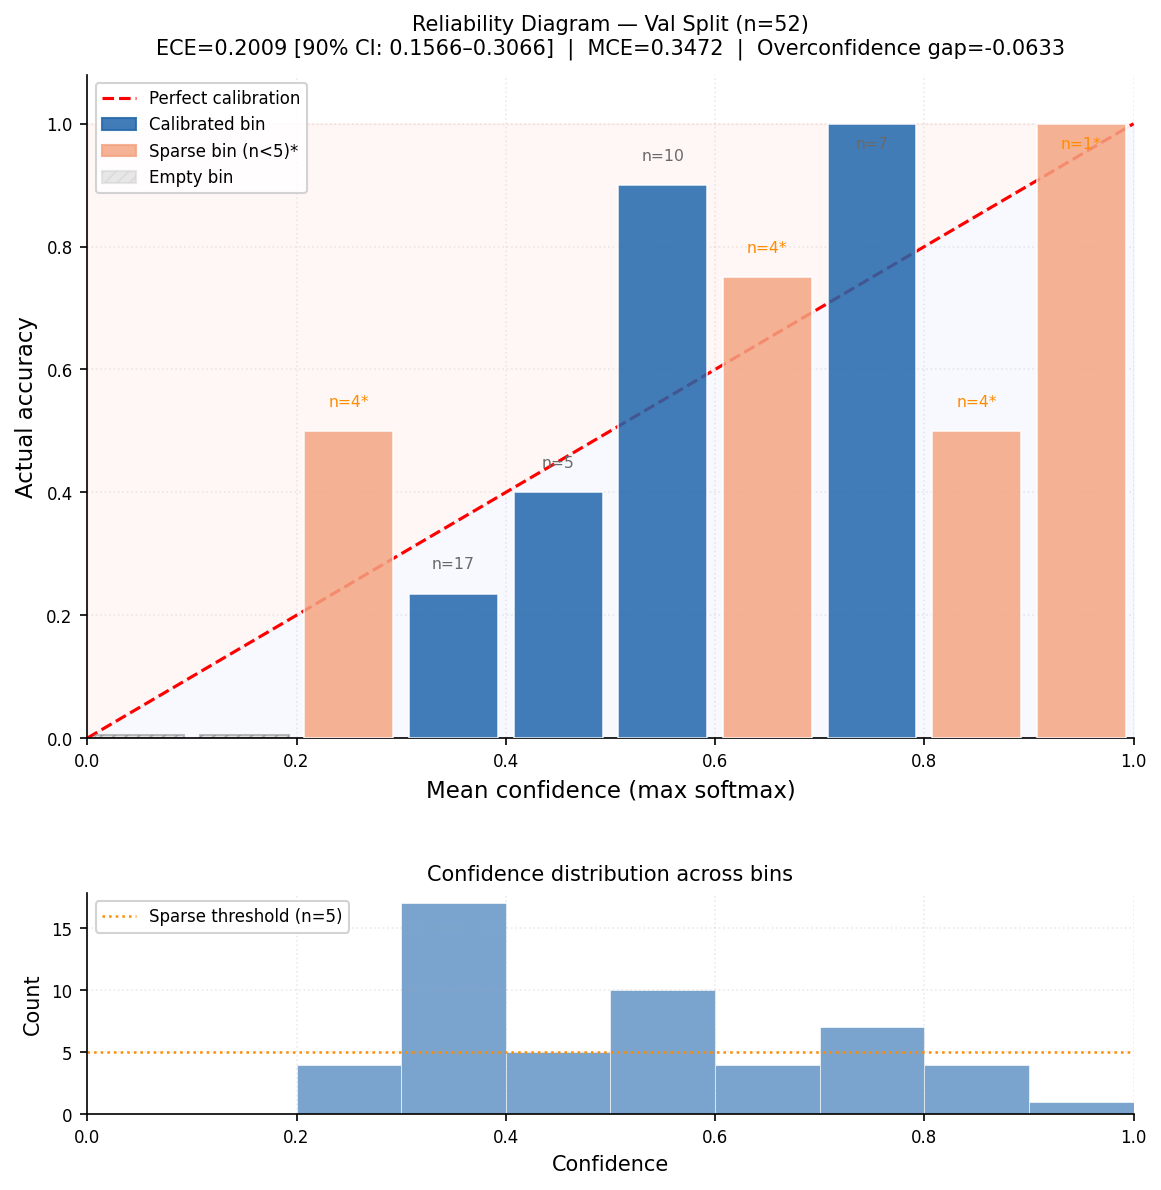


Calibration interpretation:
  Model is UNDERCONFIDENT by 0.0633.


In [15]:
# ── D2: Plot reliability diagram ─────────────────────────────────────────────
if CALIBRATION_AVAILABLE:
    SPARSE_BIN_THRESHOLD = 5

    fig6, (ax_main, ax_hist) = plt.subplots(
        2, 1, figsize=(9, 9),
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.35},
        facecolor="white",
    )

    bins_data  = val_rel["bins"]
    n_bins_len = len(bins_data)
    bin_width  = 1.0 / n_bins_len

    # Perfect calibration reference
    ax_main.plot([0, 1], [0, 1], "r--", linewidth=1.5, label="Perfect calibration")
    ax_main.fill_between([0,1],[0,0],[0,1], alpha=0.05, color="cornflowerblue", label="Underconfidence zone")
    ax_main.fill_between([0,1],[0,1],[1,1], alpha=0.05, color="tomato",         label="Overconfidence zone")

    bar_counts = []
    for bd in bins_data:
        cnt = bd.get("bin_count", 0)
        bar_counts.append(cnt)
        if cnt == 0:
            mid = (bd["bin_lo"] + bd["bin_hi"]) / 2
            ax_main.bar(mid, 0.005, width=bin_width * 0.85,
                       color="lightgrey", edgecolor="grey", hatch="////", alpha=0.5, zorder=2)
            continue

        mid = (bd["bin_lo"] + bd["bin_hi"]) / 2
        acc_val = bd["actual_accuracy"]
        is_sp   = cnt < SPARSE_BIN_THRESHOLD
        color   = PALETTE["highlight"] if is_sp else PALETTE["primary"]
        ax_main.bar(mid, acc_val, width=bin_width * 0.85,
                   color=color, alpha=0.85, edgecolor="white", linewidth=0.8, zorder=3)
        sp_mark = "*" if is_sp else ""
        ax_main.text(mid, min(acc_val + 0.04, 0.96),
                    f"n={cnt}{sp_mark}", ha="center", fontsize=7.5,
                    color="darkorange" if is_sp else "dimgrey")

    ax_main.set_xlim(0, 1)
    ax_main.set_ylim(0, 1.08)
    ax_main.set_xlabel("Mean confidence (max softmax)", fontsize=11)
    ax_main.set_ylabel("Actual accuracy",               fontsize=11)

    # ECE info
    ece_str = f"ECE={val_rel['ece']:.4f}"
    if "ece_ci_lower" in val_rel and val_rel["ece_ci_lower"] is not None:
        ece_str += f" [90% CI: {val_rel['ece_ci_lower']:.4f}–{val_rel['ece_ci_upper']:.4f}]"

    ax_main.set_title(
        f"Reliability Diagram — Val Split (n={val_rel['n_samples']})\n"
        f"{ece_str}  |  MCE={val_rel['mce']:.4f}  |  "
        f"Overconfidence gap={val_rel['overconfidence_gap']:+.4f}",
        fontsize=10, pad=10,
    )

    legend_handles = [
        mlines.Line2D([0],[0], color="red", linestyle="--", label="Perfect calibration"),
        mpatches.Patch(color=PALETTE["primary"], alpha=0.85, label="Calibrated bin"),
        mpatches.Patch(color=PALETTE["highlight"], alpha=0.85, label=f"Sparse bin (n<{SPARSE_BIN_THRESHOLD})*"),
        mpatches.Patch(color="lightgrey", hatch="////", alpha=0.5, label="Empty bin"),
    ]
    ax_main.legend(handles=legend_handles, fontsize=8, loc="upper left")
    ax_main.grid(True, alpha=0.25, linestyle=":")

    # Histogram panel
    bin_edges_plot = np.linspace(0, 1, n_bins_len + 1)
    ax_hist.bar(bin_edges_plot[:-1], bar_counts,
               width=bin_width, align="edge",
               color=PALETTE["primary"], alpha=0.6, edgecolor="white", linewidth=0.5)
    ax_hist.axhline(SPARSE_BIN_THRESHOLD, color="darkorange", linestyle=":",
                   linewidth=1.2, label=f"Sparse threshold (n={SPARSE_BIN_THRESHOLD})")
    ax_hist.set_xlabel("Confidence", fontsize=10)
    ax_hist.set_ylabel("Count",      fontsize=10)
    ax_hist.set_title("Confidence distribution across bins", fontsize=10)
    ax_hist.set_xlim(0, 1)
    ax_hist.legend(fontsize=8, loc="upper left")
    ax_hist.grid(True, alpha=0.25, linestyle=":")

    plt.savefig(FIGURES_DIR / "confidence_calibration.png", dpi=150, bbox_inches="tight", facecolor="white")
    print(f"Saved: confidence_calibration.png")
    plt.show()

    print("\nCalibration interpretation:")
    if val_rel["overconfidence_gap"] > 0:
        print(f"  Model is OVERCONFIDENT by {val_rel['overconfidence_gap']:.4f} on average.")
        print("  This is the expected direction for softmax models on small datasets.")
        print("  Remedy (documented-not-implemented): temperature scaling on logits.")
    else:
        print(f"  Model is UNDERCONFIDENT by {abs(val_rel['overconfidence_gap']):.4f}.")

2026-06-19 04:12:13 | DEBUG    | matplotlib.font_manager | findfont: Matching DejaVu Sans:style=italic:variant=normal:weight=normal:stretch=normal:size=7.0.
2026-06-19 04:12:13 | DEBUG    | matplotlib.font_manager | findfont: score(FontEntry(fname='d:\\CONDA\\conda_envs\\wlasl\\lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSansMono-Oblique.ttf', name='DejaVu Sans Mono', style='oblique', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.15
2026-06-19 04:12:13 | DEBUG    | matplotlib.font_manager | findfont: score(FontEntry(fname='d:\\CONDA\\conda_envs\\wlasl\\lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXGeneralItalic.ttf', name='STIXGeneral', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-19 04:12:13 | DEBUG    | matplotlib.font_manager | findfont: score(FontEntry(fname='d:\\CONDA\\conda_envs\\wlasl\\lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSerif-Italic.ttf', name='DejaV

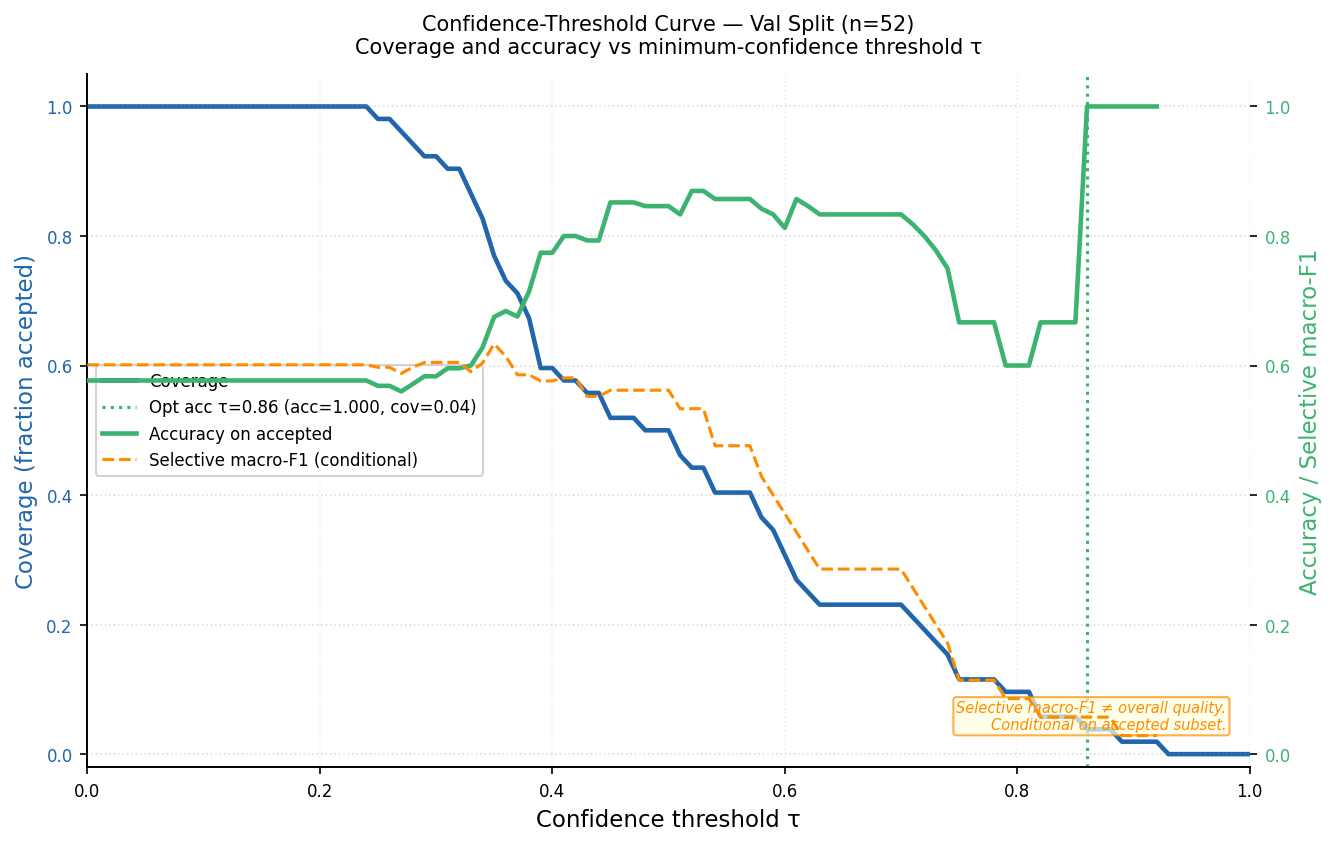

In [16]:
# ── D2: Confidence threshold curve ───────────────────────────────────────────
if CALIBRATION_AVAILABLE:
    y_prob_val = VAL_CACHE["y_prob"]
    max_conf   = y_prob_val.max(axis=1)
    y_pred_val = y_prob_val.argmax(axis=1).astype(np.int64)
    y_true_val = VAL_CACHE["y_true"]
    correct_val = (y_pred_val == y_true_val)
    n_val_total = len(y_true_val)
    labels_range = list(range(N_CLASSES))

    thresholds  = np.linspace(0.0, 1.0, 101)
    coverage    = []
    accuracy_th = []
    sel_f1      = []

    for tau in thresholds:
        accepted = max_conf >= tau
        n_acc    = int(accepted.sum())
        coverage.append(n_acc / n_val_total)
        if n_acc == 0:
            accuracy_th.append(None)
            sel_f1.append(None)
        else:
            accuracy_th.append(float(correct_val[accepted].mean()))
            sel_f1.append(float(f1_score(
                y_true_val[accepted], y_pred_val[accepted],
                average="macro", labels=labels_range, zero_division=0,
            )))

    fig7, ax1 = plt.subplots(figsize=(10, 6), facecolor="white")
    ax2 = ax1.twinx()

    ax1.plot(thresholds, coverage,
             color=PALETTE["primary"], linewidth=2.2, label="Coverage", zorder=4)
    ax1.set_xlabel("Confidence threshold τ", fontsize=11)
    ax1.set_ylabel("Coverage (fraction accepted)", color=PALETTE["primary"], fontsize=11)
    ax1.tick_params(axis="y", labelcolor=PALETTE["primary"])
    ax1.set_xlim(0, 1)
    ax1.set_ylim(-0.02, 1.05)

    acc_plot = [a if a is not None else float("nan") for a in accuracy_th]
    f1_plot  = [f if f is not None else float("nan") for f in sel_f1]

    ax2.plot(thresholds, acc_plot, color="mediumseagreen", linewidth=2.2,
             label="Accuracy on accepted", zorder=4)
    ax2.plot(thresholds, f1_plot, color="darkorange", linewidth=1.5,
             linestyle="--", label="Selective macro-F1 (conditional)", zorder=4)
    ax2.set_ylabel("Accuracy / Selective macro-F1", color="mediumseagreen", fontsize=11)
    ax2.tick_params(axis="y", labelcolor="mediumseagreen")
    ax2.set_ylim(-0.02, 1.05)

    # Optimal threshold annotations
    valid_acc = [(thresholds[i], accuracy_th[i]) for i in range(len(thresholds)) if accuracy_th[i] is not None]
    if valid_acc:
        opt_tau, opt_acc_val = max(valid_acc, key=lambda x: x[1])
        cov_at_opt = coverage[np.argmin(np.abs(thresholds - opt_tau))]
        ax1.axvline(opt_tau, color="mediumseagreen", linestyle=":", linewidth=1.5,
                   label=f"Opt acc τ={opt_tau:.2f} (acc={opt_acc_val:.3f}, cov={cov_at_opt:.2f})")

    ax2.annotate(
        "Selective macro-F1 ≠ overall quality.\nConditional on accepted subset.",
        xy=(0.98, 0.05), xycoords="axes fraction",
        ha="right", va="bottom", fontsize=7, color="darkorange", style="italic",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="lightyellow", edgecolor="darkorange", alpha=0.7),
    )

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="center left", framealpha=0.85)

    ax1.set_title(
        f"Confidence-Threshold Curve — Val Split (n={n_val_total})\n"
        "Coverage and accuracy vs minimum-confidence threshold τ",
        fontsize=10, pad=10,
    )
    ax1.grid(True, alpha=0.2, linestyle=":")

    plt.savefig(FIGURES_DIR / "confidence_threshold_curve.png", dpi=150, bbox_inches="tight", facecolor="white")
    print("Saved: confidence_threshold_curve.png")
    plt.show()

In [17]:
# ── D3: Signer generalisation analysis ───────────────────────────────────────
# All signers are unseen by construction (zero-overlap split). No familiar/novel axis.

from scipy.stats import norm as _norm
_WILSON_Z = _norm.ppf(0.95)  # z for 90% two-sided Wilson CI

def wilson_ci(n_correct: int, n_total: int) -> Tuple[float, float]:
    if n_total == 0:
        return (0.0, 0.0)
    z  = _WILSON_Z
    p  = n_correct / n_total
    n  = n_total
    d  = 1.0 + z*z / n
    c  = (p + z*z / (2*n)) / d
    m  = (z / d) * np.sqrt(p*(1-p)/n + z*z/(4*n*n))
    return (max(0.0, c - m), min(1.0, c + m))


def per_signer_stats(cache: Dict[str, Any], split_label: str) -> pd.DataFrame:
    """
    Compute per-signer accuracy, macro-F1 (global + present-classes),
    Wilson CI, and high-risk class exposure fraction.
    """
    if "signer_ids" not in cache:
        print(f"WARNING: signer_ids not in {split_label} cache — signer analysis unavailable.")
        return pd.DataFrame()

    y_true     = cache["y_true"]
    y_pred     = cache["y_pred"]
    signer_ids = cache["signer_ids"]
    correct    = (y_true == y_pred)
    labels_range = list(range(N_CLASSES))

    rows = []
    for signer in np.unique(signer_ids):
        mask       = (signer_ids == signer)
        n_clips    = int(mask.sum())
        yt_s       = y_true[mask]
        yp_s       = y_pred[mask]
        n_correct_s = int(correct[mask].sum())
        acc        = n_correct_s / n_clips if n_clips > 0 else 0.0
        ci_lo, ci_hi = wilson_ci(n_correct_s, n_clips)

        # Global macro-F1 (all 35 classes forced)
        f1_global = float(f1_score(yt_s, yp_s, average="macro",
                                   labels=labels_range, zero_division=0))

        # Present-classes macro-F1 (only classes in this signer's y_true)
        present = np.unique(yt_s).tolist()
        f1_present = float(f1_score(yt_s, yp_s, average="macro",
                                    labels=present, zero_division=0)) if present else 0.0

        # High-risk class exposure
        n_hr = int(np.isin(yt_s, list(high_risk_indices)).sum())
        hr_frac = n_hr / n_clips if n_clips > 0 else 0.0

        rows.append({
            "signer_id":                  str(signer),
            "n_clips":                    n_clips,
            "n_correct":                  n_correct_s,
            "accuracy":                   round(acc, 6),
            "ci_lower":                   round(ci_lo, 4),
            "ci_upper":                   round(ci_hi, 4),
            "macro_f1_global":            round(f1_global, 4),
            "macro_f1_present_classes":   round(f1_present, 4),
            "n_distinct_true_classes":    len(present),
            "is_sparse":                  n_clips < 5,
            "high_risk_clip_fraction":    round(hr_frac, 4),
            "split":                      split_label,
        })

    return pd.DataFrame(rows).sort_values("accuracy", ascending=True).reset_index(drop=True)


val_signer_df  = per_signer_stats(VAL_CACHE,  "val")
test_signer_df = per_signer_stats(TEST_CACHE, "test")

SIGNER_ANALYSIS_AVAILABLE = len(val_signer_df) > 0

if SIGNER_ANALYSIS_AVAILABLE:
    print("=== VAL SIGNER ANALYSIS ===")
    cols = ["signer_id","n_clips","n_correct","accuracy","ci_lower","ci_upper",
            "macro_f1_global","macro_f1_present_classes","is_sparse","high_risk_clip_fraction"]
    print(val_signer_df[cols].to_string(index=False))
    print(f"\nVal:  accuracy range [{val_signer_df['accuracy'].min():.3f}, {val_signer_df['accuracy'].max():.3f}]")
    print(f"      std = {val_signer_df['accuracy'].std(ddof=1):.4f}")
    if len(test_signer_df) > 0:
        print(f"\nTest: accuracy range [{test_signer_df['accuracy'].min():.3f}, {test_signer_df['accuracy'].max():.3f}]")
        print(f"      std = {test_signer_df['accuracy'].std(ddof=1):.4f}")

=== VAL SIGNER ANALYSIS ===
signer_id  n_clips  n_correct  accuracy  ci_lower  ci_upper  macro_f1_global  macro_f1_present_classes  is_sparse  high_risk_clip_fraction
       93        1          0  0.000000    0.0000    0.7301           0.0000                    0.0000       True                      0.0
       96        1          0  0.000000    0.0000    0.7301           0.0000                    0.0000       True                      0.0
       94        5          1  0.200000    0.0460    0.5647           0.0286                    0.2500      False                      0.0
       41        9          4  0.444444    0.2180    0.6965           0.1048                    0.5238      False                      0.0
       12       31         20  0.645161    0.4975    0.7696           0.4810                    0.6474      False                      0.0
       17        2          2  1.000000    0.4250    1.0000           0.0571                    1.0000       True                      0.0

2026-06-19 04:13:14 | DEBUG    | matplotlib.font_manager | findfont: Matching DejaVu Sans:style=normal:variant=normal:weight=normal:stretch=normal:size=8.5.
2026-06-19 04:13:14 | DEBUG    | matplotlib.font_manager | findfont: score(FontEntry(fname='d:\\CONDA\\conda_envs\\wlasl\\lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSansMono-Oblique.ttf', name='DejaVu Sans Mono', style='oblique', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
2026-06-19 04:13:14 | DEBUG    | matplotlib.font_manager | findfont: score(FontEntry(fname='d:\\CONDA\\conda_envs\\wlasl\\lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXGeneralItalic.ttf', name='STIXGeneral', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
2026-06-19 04:13:14 | DEBUG    | matplotlib.font_manager | findfont: score(FontEntry(fname='d:\\CONDA\\conda_envs\\wlasl\\lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSerif-Italic.ttf', name='DejaV

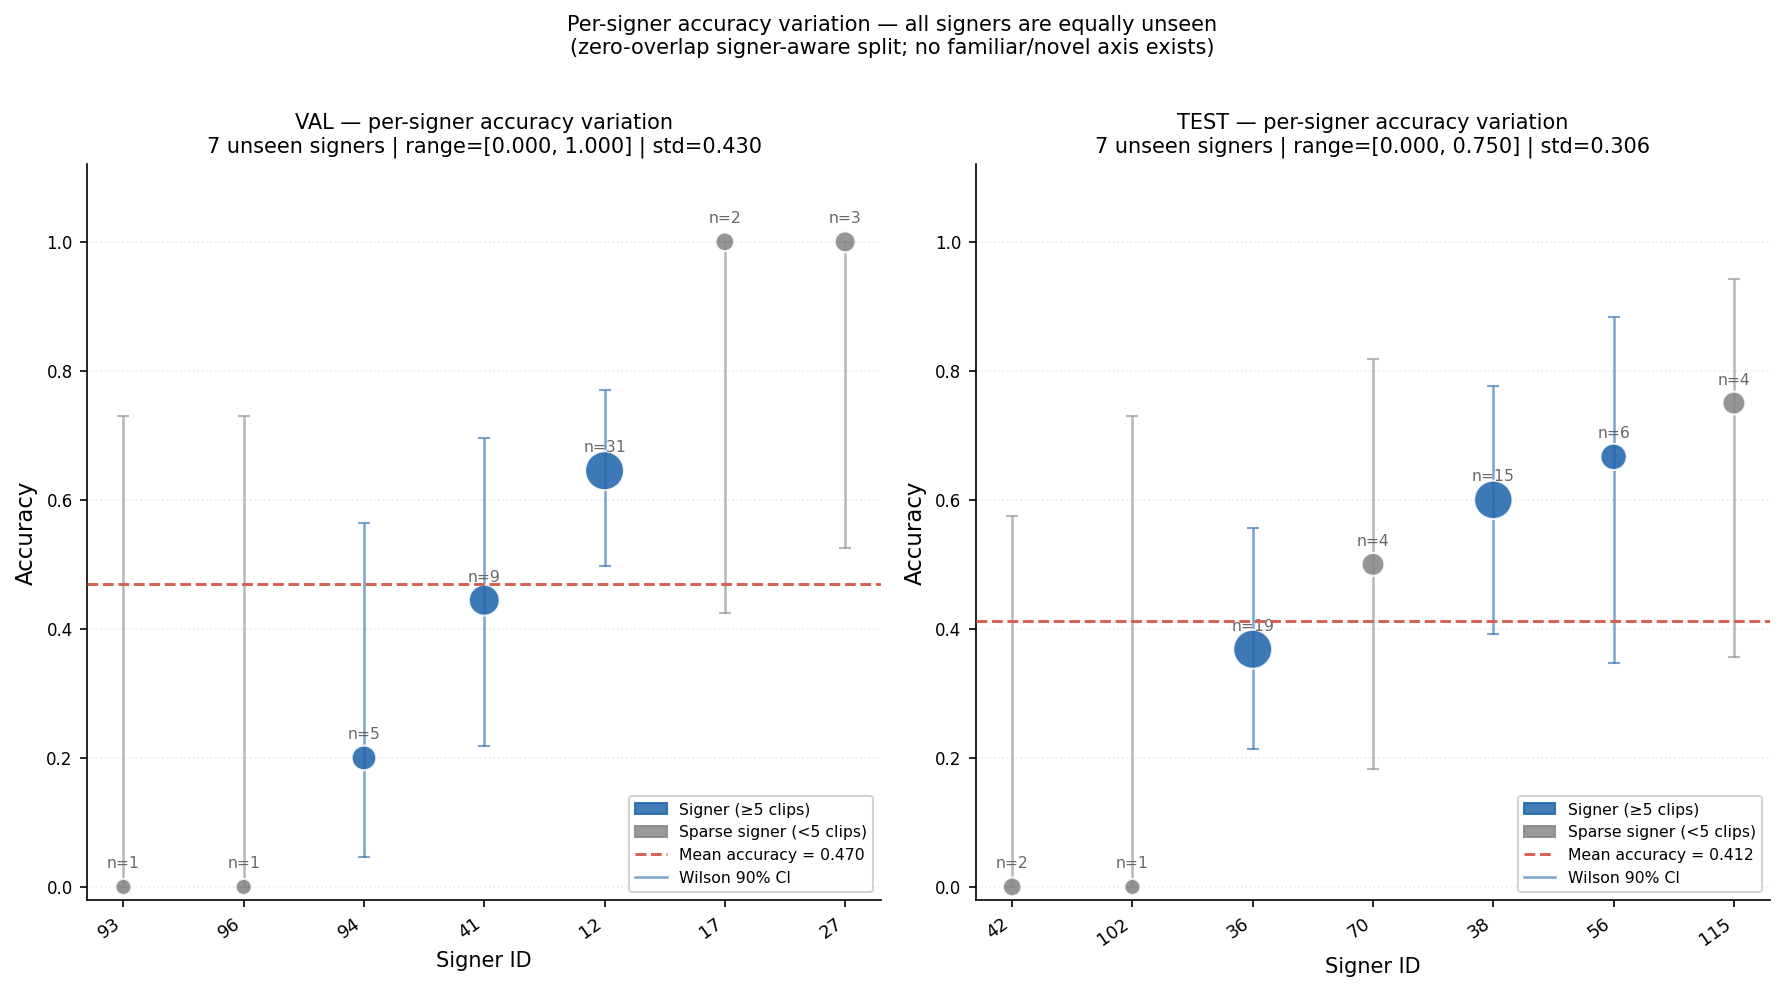

In [18]:
# ── D3: Signer generalisation plot ───────────────────────────────────────────
if SIGNER_ANALYSIS_AVAILABLE:
    panels = [("val", val_signer_df)]
    if len(test_signer_df) > 0:
        panels.append(("test", test_signer_df))

    n_panels = len(panels)
    fig8, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 6.5),
                              squeeze=False, facecolor="white")

    SPARSE_THRESHOLD = 5
    MAX_MARKER       = 350

    for col, (split_label, df) in enumerate(panels):
        ax = axes[0][col]
        if df.empty:
            ax.set_visible(False)
            continue

        n_s       = len(df)
        x         = np.arange(n_s)
        sizes     = [min(40 + 20 * r.n_clips, MAX_MARKER) for r in df.itertuples()]
        colors    = [PALETTE["neutral"] if r.is_sparse else PALETTE["primary"] for r in df.itertuples()]
        acc_vals  = df["accuracy"].values
        overall   = float(acc_vals.mean()) if n_s > 0 else 0.0

        ax.scatter(x, acc_vals, s=sizes, c=colors, alpha=0.88,
                  edgecolor="white", linewidth=1.0, zorder=3)

        # Wilson CI error bars
        for i, row in df.reset_index(drop=True).iterrows():
            ax.errorbar(
                i, row["accuracy"],
                yerr=[[row["accuracy"] - row["ci_lower"]],
                      [row["ci_upper"] - row["accuracy"]]],
                fmt="none",
                color=PALETTE["neutral"] if row["is_sparse"] else PALETTE["primary"],
                linewidth=1.2, capsize=3, capthick=1.0, alpha=0.6, zorder=2,
            )

        # n= annotations
        for i, row in df.reset_index(drop=True).iterrows():
            ax.annotate(
                f"n={row['n_clips']}",
                (i, row["accuracy"]),
                textcoords="offset points",
                xytext=(0, 9), ha="center", fontsize=7.5, color="dimgrey",
            )

        # Pooled accuracy line
        ax.axhline(overall, color=PALETTE["secondary"], linestyle="--",
                  linewidth=1.4, zorder=4)

        ax.set_xticks(x)
        ax.set_xticklabels(df["signer_id"].tolist(), rotation=35, ha="right", fontsize=8.5)
        ax.set_ylim(-0.02, 1.12)
        ax.set_ylabel("Accuracy", fontsize=11)
        ax.set_xlabel("Signer ID", fontsize=10)

        n_sp = int(df["is_sparse"].sum())
        acc_range = f"[{acc_vals.min():.3f}, {acc_vals.max():.3f}]"
        ax.set_title(
            f"{split_label.upper()} — per-signer accuracy variation\n"
            f"{n_s} unseen signers | range={acc_range} | std={acc_vals.std(ddof=1):.3f}",
            fontsize=10,
        )

        legend_handles = [
            mpatches.Patch(color=PALETTE["primary"], alpha=0.85, label="Signer (≥5 clips)"),
            mpatches.Patch(color=PALETTE["neutral"],  alpha=0.85, label=f"Sparse signer (<{SPARSE_THRESHOLD} clips)"),
            mlines.Line2D([0],[0], color=PALETTE["secondary"], linestyle="--", linewidth=1.4,
                         label=f"Mean accuracy = {overall:.3f}"),
            mlines.Line2D([0],[0], color=PALETTE["primary"], linewidth=1.2, alpha=0.6,
                         label="Wilson 90% CI"),
        ]
        ax.legend(handles=legend_handles, fontsize=7.5, loc="lower right", framealpha=0.85)
        ax.grid(True, axis="y", alpha=0.25, linestyle=":")

    fig8.suptitle(
        "Per-signer accuracy variation — all signers are equally unseen\n"
        "(zero-overlap signer-aware split; no familiar/novel axis exists)",
        fontsize=10, y=1.01,
    )
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "signer_generalisation.png", dpi=150, bbox_inches="tight", facecolor="white")
    print("Saved: signer_generalisation.png")
    plt.show()

    # Pearson + Spearman correlation (accuracy vs high-risk exposure)
    if "high_risk_clip_fraction" in val_signer_df.columns:
        from scipy.stats import pearsonr, spearmanr
        acc_v = val_signer_df["accuracy"].values
        hr_v  = val_signer_df["high_risk_clip_fraction"].values

        if len(acc_v) >= 3 and acc_v.std() > 0 and hr_v.std() > 0:
            r_p, p_p = pearsonr(acc_v, hr_v)
            r_s, p_s = spearmanr(acc_v, hr_v)
            print(f"\nAccuracy vs High-Risk Exposure correlation (n={len(acc_v)} signers):")
            print(f"  Pearson  r   = {r_p:.4f}  (p={p_p:.4f})")
            print(f"  Spearman rho = {r_s:.4f}  (p={p_s:.4f})")
            print("  NOTE: n=7 — treat as descriptive/exploratory only.")

In [19]:
# ── D4: Failure taxonomy — built from actual misclassifications ───────────────

def build_failure_taxonomy(
    cache: Dict[str, Any],
    split_label: str,
    pcdf: pd.DataFrame,
) -> Dict[str, Any]:
    """
    Inductive failure taxonomy from actual misclassified clips.
    Tests whether errors cluster in:
      (a) Zero-filled / low-detection clips (detected_frame_count / missing_pct)
      (b) High-risk true classes (Stage 5 Finding 8)
      (c) Low-support true classes (singletons)
    """
    y_true  = cache["y_true"]
    y_pred  = cache["y_pred"]
    correct = (y_true == y_pred)
    n_total = len(y_true)

    taxonomy: Dict[str, Any] = {
        "split":           split_label,
        "n_total":         n_total,
        "n_correct":       int(correct.sum()),
        "n_incorrect":     int((~correct).sum()),
        "overall_accuracy": float(correct.mean()),
    }

    # Category A: high-risk class failures
    hr_mask    = np.isin(y_true, list(high_risk_indices))
    taxonomy["high_risk_clips"] = {
        "n_total":   int(hr_mask.sum()),
        "n_correct": int((correct & hr_mask).sum()),
        "n_error":   int((~correct & hr_mask).sum()),
        "accuracy":  float((correct & hr_mask).sum() / hr_mask.sum()) if hr_mask.sum() > 0 else None,
    }
    taxonomy["high_risk_clips"]["error_rate"] = (
        taxonomy["high_risk_clips"]["n_error"] / taxonomy["high_risk_clips"]["n_total"]
        if taxonomy["high_risk_clips"]["n_total"] > 0 else None
    )

    # Category B: singleton class failures
    singleton_indices = set(pcdf[pcdf["is_singleton"]]["class_idx"].tolist()) if not pcdf.empty else set()
    sing_mask = np.isin(y_true, list(singleton_indices))
    taxonomy["singleton_clips"] = {
        "n_total":   int(sing_mask.sum()),
        "n_correct": int((correct & sing_mask).sum()),
        "n_error":   int((~correct & sing_mask).sum()),
        "accuracy":  float((correct & sing_mask).sum() / sing_mask.sum()) if sing_mask.sum() > 0 else None,
    }

    # Category C: zero-fill / low-detection failures
    for meta_field, label, rescale in [
        ("detected_frame_count", "Detected frames", False),
        ("missing_pct",          "Missing pct",     True),
    ]:
        if meta_field not in cache:
            continue
        vals = cache[meta_field].astype(np.float64)
        if rescale and vals.max() > 1.0:
            vals = vals / 100.0
        median_corr  = np.nanmedian(vals[correct])
        median_err   = np.nanmedian(vals[~correct])
        taxonomy[meta_field] = {
            "median_correct":   float(median_corr),
            "median_error":     float(median_err),
            "direction":        "errors in lower-detection clips" if label == "Detected frames" and median_err < median_corr
                                else "errors in higher-missing-pct clips" if label == "Missing pct" and median_err > median_corr
                                else "no clear directional signal",
        }

    # think class specifically (3 train clips, F1=0.0 in 8/9 champion runs)
    if "think" in name_to_idx:
        think_idx  = name_to_idx["think"]
        think_mask = y_true == think_idx
        taxonomy["think_class"] = {
            "n_total":   int(think_mask.sum()),
            "n_correct": int((correct & think_mask).sum()),
            "f1_score":  float(pcdf[pcdf["sign"] == "think"]["f1_score"].values[0]) if not pcdf.empty and "think" in pcdf["sign"].values else None,
        }

    return taxonomy


val_taxonomy  = build_failure_taxonomy(VAL_CACHE,  "val",  val_pcdf)
test_taxonomy = build_failure_taxonomy(TEST_CACHE, "test", test_pcdf)

print("=== FAILURE TAXONOMY — VAL ===")
print(f"  n_total     : {val_taxonomy['n_total']}")
print(f"  n_correct   : {val_taxonomy['n_correct']}")
print(f"  n_incorrect : {val_taxonomy['n_incorrect']}")
print(f"  accuracy    : {val_taxonomy['overall_accuracy']:.4f}")
print(f"\n  High-risk clips  : {val_taxonomy['high_risk_clips']}")
print(f"  Singleton clips  : {val_taxonomy['singleton_clips']}")
if "think" in val_taxonomy:
    print(f"  think class     : {val_taxonomy['think_class']}")
for field in ("detected_frame_count", "missing_pct"):
    if field in val_taxonomy:
        d = val_taxonomy[field]
        print(f"\n  {field}:")
        print(f"    median (correct)   = {d['median_correct']:.3f}")
        print(f"    median (incorrect) = {d['median_error']:.3f}")
        print(f"    direction: {d['direction']}")

print("\n=== FAILURE TAXONOMY — TEST ===")
print(f"  n_total     : {test_taxonomy['n_total']}")
print(f"  n_incorrect : {test_taxonomy['n_incorrect']}")

=== FAILURE TAXONOMY — VAL ===
  n_total     : 52
  n_correct   : 30
  n_incorrect : 22
  accuracy    : 0.5769

  High-risk clips  : {'n_total': 0, 'n_correct': 0, 'n_error': 0, 'accuracy': None, 'error_rate': None}
  Singleton clips  : {'n_total': 21, 'n_correct': 17, 'n_error': 4, 'accuracy': 0.8095238095238095}

  detected_frame_count:
    median (correct)   = 86.000
    median (incorrect) = 82.500
    direction: errors in lower-detection clips

  missing_pct:
    median (correct)   = 0.565
    median (incorrect) = 0.598
    direction: errors in higher-missing-pct clips

=== FAILURE TAXONOMY — TEST ===
  n_total     : 51
  n_incorrect : 26


2026-06-19 04:15:55 | DEBUG    | matplotlib.font_manager | findfont: Matching DejaVu Sans:style=normal:variant=normal:weight=bold:stretch=normal:size=9.0.
2026-06-19 04:15:55 | DEBUG    | matplotlib.font_manager | findfont: score(FontEntry(fname='d:\\CONDA\\conda_envs\\wlasl\\lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSansMono-Oblique.ttf', name='DejaVu Sans Mono', style='oblique', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.335
2026-06-19 04:15:55 | DEBUG    | matplotlib.font_manager | findfont: score(FontEntry(fname='d:\\CONDA\\conda_envs\\wlasl\\lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXGeneralItalic.ttf', name='STIXGeneral', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.335
2026-06-19 04:15:55 | DEBUG    | matplotlib.font_manager | findfont: score(FontEntry(fname='d:\\CONDA\\conda_envs\\wlasl\\lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSerif-Italic.ttf', name='DejaV

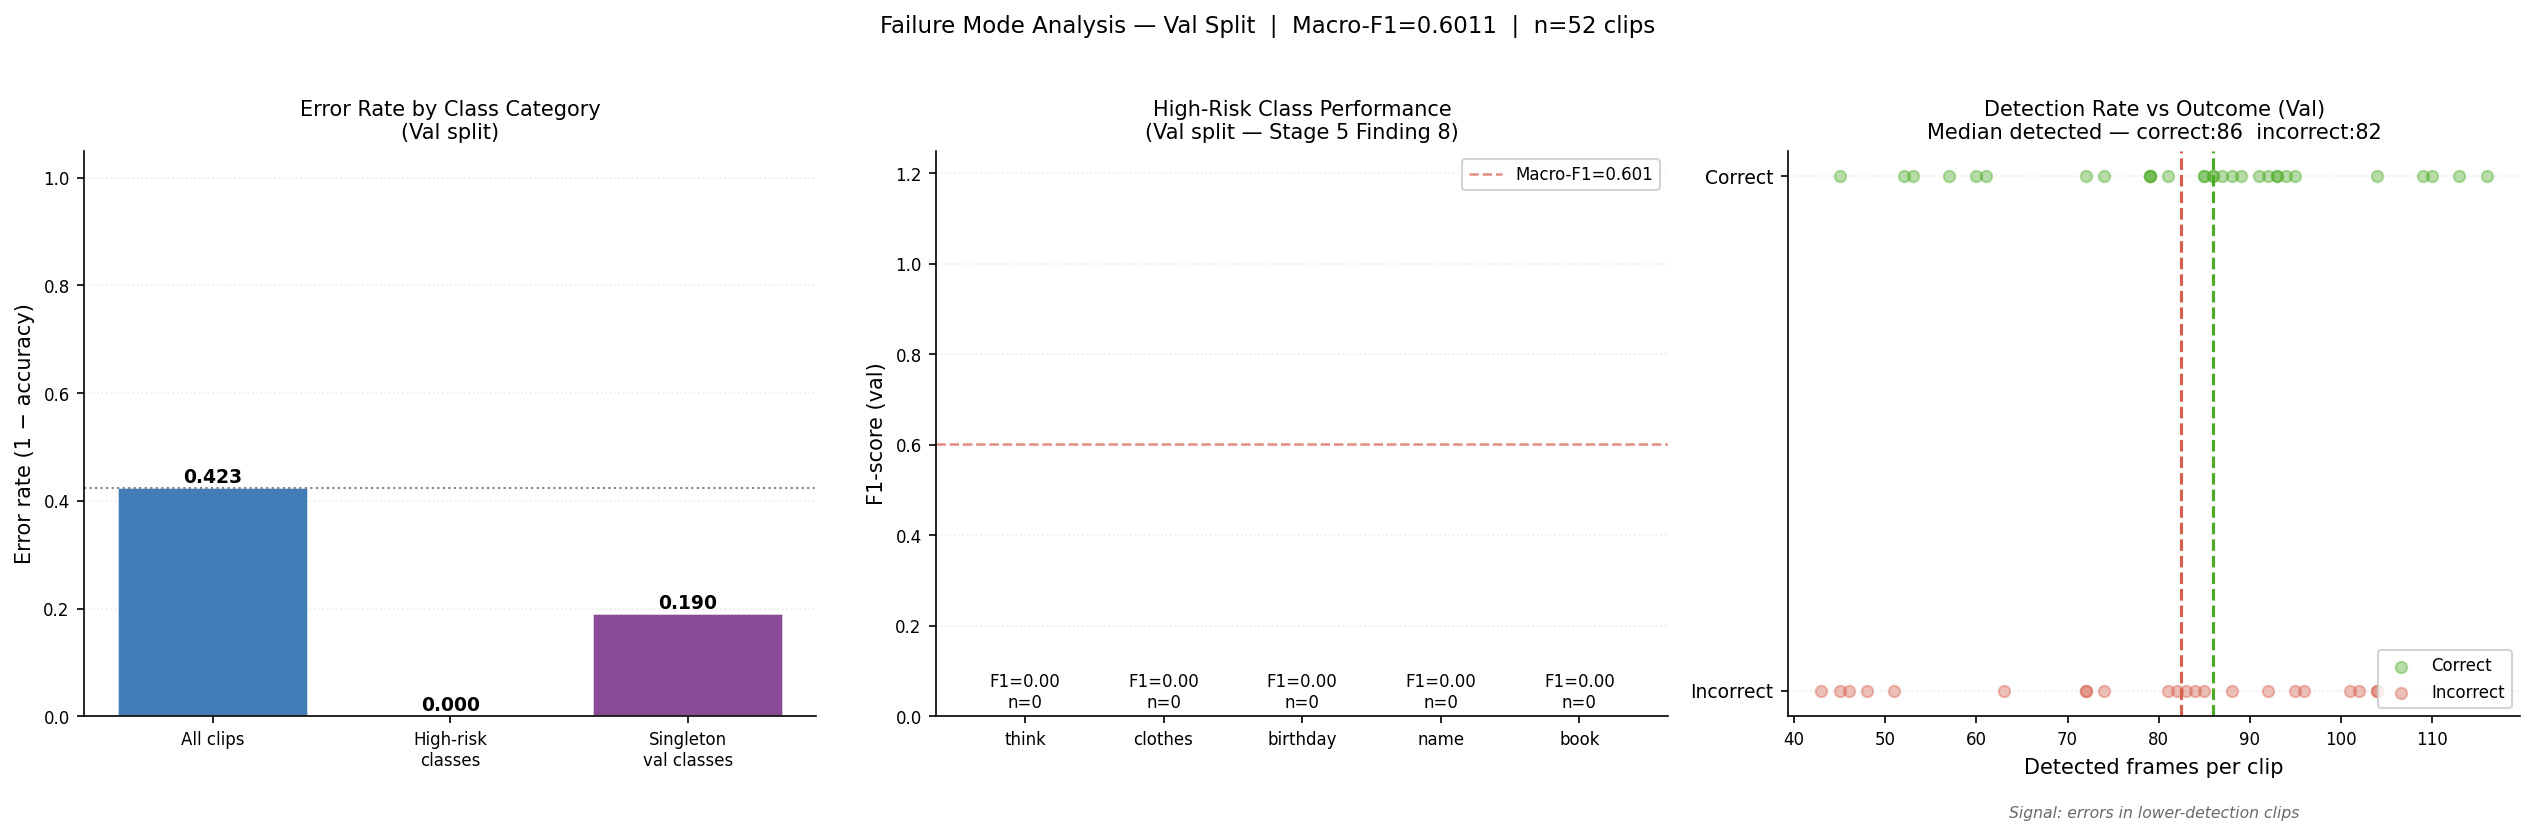

In [21]:
# ── D4: Failure mode visualisation ────────────────────────────────────────────

HAS_META = "detected_frame_count" in VAL_CACHE or "missing_pct" in VAL_CACHE

fig9, axes9 = plt.subplots(1, 3, figsize=(17, 5.5), facecolor="white")

# ── Panel 1: error rate by class category ────────────────────────────────────
ax = axes9[0]
cats = ["All clips", "High-risk\nclasses", "Singleton\nval classes"]
error_rates_val = [
    1.0 - val_taxonomy["overall_accuracy"],
    val_taxonomy["high_risk_clips"]["error_rate"] if val_taxonomy["high_risk_clips"]["error_rate"] is not None else 0.0,
    1.0 - (val_taxonomy["singleton_clips"]["accuracy"] or 0.0),
]
colors_cats = [PALETTE["primary"], PALETTE["high_risk"], PALETTE["singleton"]]
bar_cats = ax.bar(cats, error_rates_val, color=colors_cats, alpha=0.85, edgecolor="white", linewidth=0.8)
ax.axhline(1.0 - val_taxonomy["overall_accuracy"], color="grey", linestyle=":", linewidth=1.0)
for bar, val in zip(bar_cats, error_rates_val):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", fontsize=9, fontweight="bold")
ax.set_ylabel("Error rate (1 − accuracy)", fontsize=10)
ax.set_title("Error Rate by Class Category\n(Val split)", fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(True, axis="y", alpha=0.25, linestyle=":")
ax.set_axisbelow(True)

# ── Panel 2: think class deep dive ───────────────────────────────────────────
ax = axes9[1]
think_data = val_taxonomy.get("think_class", {})
signs_spotlight = ["think", "clothes", "birthday", "name", "book"]
f1_spotlight = []
support_spotlight = []
for sn in signs_spotlight:
    row = val_pcdf[val_pcdf["sign"] == sn]
    if len(row):
        f1_spotlight.append(float(row["f1_score"].values[0]))
        support_spotlight.append(int(row["support"].values[0]))
    else:
        f1_spotlight.append(0.0)
        support_spotlight.append(0)

bars_hr = ax.bar(signs_spotlight, f1_spotlight, color=PALETTE["high_risk"], alpha=0.85, edgecolor="white")
for bar, f1, sup in zip(bars_hr, f1_spotlight, support_spotlight):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"F1={f1:.2f}\nn={sup}", ha="center", fontsize=8)
ax.set_ylabel("F1-score (val)", fontsize=10)
ax.set_title("High-Risk Class Performance\n(Val split — Stage 5 Finding 8)", fontsize=10)
ax.set_ylim(0, 1.25)
ax.axhline(val_macro_f1, color=PALETTE["secondary"], linestyle="--", linewidth=1.2, alpha=0.7, label=f"Macro-F1={val_macro_f1:.3f}")
ax.legend(fontsize=8)
ax.grid(True, axis="y", alpha=0.25, linestyle=":")

# ── Panel 3: detection-rate vs error (if metadata available) ─────────────────
ax = axes9[2]
if HAS_META and "detected_frame_count" in VAL_CACHE:
    dfc  = VAL_CACHE["detected_frame_count"].astype(float)
    corr = (VAL_CACHE["y_true"] == VAL_CACHE["y_pred"])

    ax.scatter(dfc[corr],  np.ones(int(corr.sum()))   * 1.0, alpha=0.4, color=PALETTE["success"],   s=30, label="Correct")
    ax.scatter(dfc[~corr], np.ones(int((~corr).sum())) * 0.0, alpha=0.4, color=PALETTE["secondary"], s=30, label="Incorrect")
    ax.axvline(np.nanmedian(dfc[corr]),  color=PALETTE["success"],    linestyle="--", linewidth=1.5)
    ax.axvline(np.nanmedian(dfc[~corr]), color=PALETTE["secondary"],  linestyle="--", linewidth=1.5)
    ax.set_xlabel("Detected frames per clip", fontsize=10)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Incorrect", "Correct"], fontsize=9)
    ax.set_title(
        f"Detection Rate vs Outcome (Val)\n"
        f"Median detected — correct:{np.nanmedian(dfc[corr]):.0f}  incorrect:{np.nanmedian(dfc[~corr]):.0f}",
        fontsize=10,
    )
    ax.legend(fontsize=8)
    direction = val_taxonomy.get("detected_frame_count", {}).get("direction", "")
    ax.annotate(f"Signal: {direction}", xy=(0.5, -0.18), xycoords="axes fraction",
               ha="center", fontsize=7.5, color="dimgrey", style="italic")
else:
    ax.text(0.5, 0.5, "Metadata (detected_frame_count)\nnot in prediction cache.\nRe-run Phase B1 with\nenriched cache schema.",
           ha="center", va="center", fontsize=9, color="dimgrey",
           transform=ax.transAxes, style="italic")
    ax.set_visible(True)
    ax.set_title("Detection Rate vs Outcome", fontsize=10)

# Remove the accidental walrus usage (Python 3.7 compatibility)
plt.suptitle(
    f"Failure Mode Analysis — Val Split  |  Macro-F1={val_macro_f1:.4f}  |  n={VAL_CACHE['n_samples']} clips",
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "failure_mode_analysis.png", dpi=150, bbox_inches="tight", facecolor="white")
print("Saved: failure_mode_analysis.png")
plt.show()

In [22]:
# ── Consolidated summary table ────────────────────────────────────────────────

summary_rows = [
    # Headline metrics
    {"Metric": "Val macro-F1 (point estimate)", "Value": f"{val_macro_f1:.4f}", "Notes": "Primary metric"},
    {"Metric": f"Val macro-F1 90% CI", "Value": f"[{val_ci['ci_lower']:.4f}, {val_ci['ci_upper']:.4f}]", "Notes": f"Class-stratified bootstrap, n={val_ci['n_bootstrap']}"},
    {"Metric": "Val accuracy",          "Value": f"{VAL_CACHE['overall_accuracy']:.4f}", "Notes": "Secondary metric only"},
    {"Metric": "Val n_samples",         "Value": str(VAL_CACHE["n_samples"]),             "Notes": "52 clips, 7 unseen signers"},
    {"Metric": "Test macro-F1 (point)", "Value": f"{test_macro_f1:.4f}",                  "Notes": "One-shot evaluation — never re-run"},
    {"Metric": f"Test macro-F1 90% CI", "Value": f"[{test_ci['ci_lower']:.4f}, {test_ci['ci_upper']:.4f}]", "Notes": f"n={test_ci['n_bootstrap']}"},
    {"Metric": "Test accuracy",         "Value": f"{TEST_CACHE['overall_accuracy']:.4f}", "Notes": "Secondary metric"},
    {"Metric": "Test n_samples",        "Value": str(TEST_CACHE["n_samples"]),             "Notes": "51 clips, 7 unseen signers"},
    # Gap analysis
    {"Metric": "Val→Test macro-F1 gap", "Value": f"{val_macro_f1 - test_macro_f1:+.4f}", "Notes": "Expected: indirect val-set overfitting via epoch selection"},
    # Calibration
]

if CALIBRATION_AVAILABLE:
    summary_rows += [
        {"Metric": "ECE (val)",             "Value": f"{val_rel['ece']:.4f}",                "Notes": "Expected Calibration Error — overconfident if > 0"},
        {"Metric": "MCE (val)",             "Value": f"{val_rel['mce']:.4f}",                "Notes": "Maximum Calibration Error"},
        {"Metric": "Overconfidence gap",    "Value": f"{val_rel['overconfidence_gap']:+.4f}", "Notes": "mean_confidence − mean_accuracy"},
    ]

# High-risk class F1 (val)
for sign in HIGH_RISK_SIGNS:
    row = val_pcdf[val_pcdf["sign"] == sign]
    if len(row):
        f1_v = float(row["f1_score"].values[0])
        sup  = int(row["support"].values[0])
        flag = "⚠ UNLEARNABLE" if f1_v == 0.0 else ("⚠ LOW" if f1_v < 0.20 else "")
        summary_rows.append({"Metric": f"F1 — {sign} (val)", "Value": f"{f1_v:.4f} (n={sup})", "Notes": flag})

summary_df = pd.DataFrame(summary_rows)
print("=" * 75)
print("PHASE D — COMPLETE EVALUATION SUMMARY")
print("=" * 75)
print(summary_df.to_string(index=False))
print("=" * 75)

PHASE D — COMPLETE EVALUATION SUMMARY
                       Metric            Value                                                      Notes
Val macro-F1 (point estimate)           0.6011                                             Primary metric
          Val macro-F1 90% CI [0.5534, 0.6410]                         Class-stratified bootstrap, n=1000
                 Val accuracy           0.5769                                      Secondary metric only
                Val n_samples               52                                 52 clips, 7 unseen signers
        Test macro-F1 (point)           0.4581                         One-shot evaluation — never re-run
         Test macro-F1 90% CI [0.3935, 0.5076]                                                     n=1000
                Test accuracy           0.4902                                           Secondary metric
               Test n_samples               51                                 51 clips, 7 unseen signers
        

In [23]:
# ── Write evaluation_report.json ──────────────────────────────────────────────
import json
from datetime import datetime

EARLY_STOPPING_MONITOR_DISCREPANCY_NOTE = (
    "Champion config_snapshot.yaml confirms early_stopping_monitor=val_accuracy, "
    "NOT val_macro_f1 as narrated in the Stage 5 handoff. Champion selection "
    "used manual MacroF1Evaluator in train.py (best_val_macro_f1 tracked separately). "
    "The Keras early-stopping monitor (val_accuracy) does not affect which weights "
    "were checkpointed — the manual macro-F1 counter controlled that. Discrepancy "
    "is informational; it does not invalidate the reported val_macro_f1=0.6011."
)

report = {
    "generated_at":        datetime.utcnow().isoformat() + "Z",
    "champion_run":        CHAMPION_RUN,
    "phase_d_notebook":    "notebooks/06_evaluation_error_analysis.ipynb",
    "config_discrepancy":  EARLY_STOPPING_MONITOR_DISCREPANCY_NOTE,
    "val": {
        "n_samples":        VAL_CACHE["n_samples"],
        "macro_f1":         round(val_macro_f1, 6),
        "accuracy":         round(VAL_CACHE["overall_accuracy"], 6),
        "macro_f1_ci": {
            "ci_lower":    round(val_ci["ci_lower"], 6),
            "ci_upper":    round(val_ci["ci_upper"], 6),
            "ci_level":    val_ci["ci_level"],
            "ci_width":    round(val_ci["ci_width"], 6),
            "n_bootstrap": val_ci["n_bootstrap"],
            "resampling_unit": "clip (class-stratified, NOT signer-aware)",
        },
    },
    "test": {
        "n_samples":        TEST_CACHE["n_samples"],
        "macro_f1":         round(test_macro_f1, 6),
        "accuracy":         round(TEST_CACHE["overall_accuracy"], 6),
        "macro_f1_ci": {
            "ci_lower":    round(test_ci["ci_lower"], 6),
            "ci_upper":    round(test_ci["ci_upper"], 6),
            "ci_level":    test_ci["ci_level"],
            "ci_width":    round(test_ci["ci_width"], 6),
            "n_bootstrap": test_ci["n_bootstrap"],
            "resampling_unit": "clip (class-stratified, NOT signer-aware)",
        },
        "test_pre_commitment_log": "reports/test_evaluation_log.md",
        "first_and_final_evaluation": True,
    },
    "val_test_gap": {
        "macro_f1_gap":  round(val_macro_f1 - test_macro_f1, 6),
        "interpretation": (
            "Indirect val-set overfitting: champion hyperparameters (epoch budget, "
            "augmentation strategy, landmark config) were selected based on val performance. "
            "Test provides the unbiased estimate. Gap is expected and not evidence of leakage "
            "(splits are signer-aware with zero overlap)."
        ),
    },
    "high_risk_class_f1_val": {
        row["sign"]: {"f1": float(row["f1_score"]), "support": int(row["support"])}
        for _, row in val_pcdf[val_pcdf["is_high_risk"]].iterrows()
    },
    "figures_produced": [
        "confusion_matrix_best_model.png",
        "confusion_matrix_normalised.png",
        "confusion_matrix_test.png",
        "per_class_metrics.png",
        "per_class_metrics_test.png",
        "confidence_calibration.png",
        "confidence_threshold_curve.png",
        "signer_generalisation.png",
        "failure_mode_analysis.png",
    ],
    "phase_d_completion_status": "COMPLETE",
}

if CALIBRATION_AVAILABLE:
    report["val"]["calibration"] = {
        "ece":                val_rel["ece"],
        "ece_unweighted":     val_rel["ece_unweighted"],
        "mce":                val_rel["mce"],
        "overconfidence_gap": val_rel["overconfidence_gap"],
        "mean_confidence":    val_rel["mean_confidence"],
        "mean_accuracy":      val_rel["mean_accuracy"],
        "temperature_scaling_note": (
            "Temperature scaling (dividing pre-softmax logits by scalar T) is "
            "the standard post-hoc calibration remedy. Not implemented in Stage 6 "
            "because this module receives post-softmax probabilities. "
            "See LIMITATIONS.md."
        ),
    }

eval_report_path = EVAL_DIR / "evaluation_report.json"
with open(eval_report_path, "w") as f:
    json.dump(report, f, indent=2)

print(f"evaluation_report.json written to: {eval_report_path}")
print(f"\nKey numbers:")
print(f"  Val  macro-F1 : {report['val']['macro_f1']:.4f}  [90% CI: {report['val']['macro_f1_ci']['ci_lower']:.4f}–{report['val']['macro_f1_ci']['ci_upper']:.4f}]")
print(f"  Test macro-F1 : {report['test']['macro_f1']:.4f}  [90% CI: {report['test']['macro_f1_ci']['ci_lower']:.4f}–{report['test']['macro_f1_ci']['ci_upper']:.4f}]")
print(f"  Val→Test gap  : {report['val_test_gap']['macro_f1_gap']:+.4f}")

evaluation_report.json written to: d:\PROJECTS\WLASL-Gesture-Recognition-System\reports\evaluation\evaluation_report.json

Key numbers:
  Val  macro-F1 : 0.6011  [90% CI: 0.5534–0.6410]
  Test macro-F1 : 0.4581  [90% CI: 0.3935–0.5076]
  Val→Test gap  : +0.1430


In [ ]:
# ── Append Stage 6 findings to LIMITATIONS.md ────────────────────────────────
LIMITATIONS_PATH = REPO_ROOT / "LIMITATIONS.md"

stage6_addendum = f"""

---

## Stage 6 Additions (Phase D — {datetime.utcnow().strftime('%Y-%m-%d')})

### Metric uncertainty
- Val macro-F1 point estimate: **{val_macro_f1:.4f}** (90% CI: [{val_ci['ci_lower']:.4f}, {val_ci['ci_upper']:.4f}])
- Test macro-F1 point estimate: **{test_macro_f1:.4f}** (90% CI: [{test_ci['ci_lower']:.4f}, {test_ci['ci_upper']:.4f}])
- Bootstrap is class-stratified clip-level resampling — NOT signer-aware. Within-signer error correlation means this CI likely understates true uncertainty.
- Val→Test macro-F1 gap: {val_macro_f1 - test_macro_f1:+.4f}. Attributed to indirect val-set overfitting (epoch and hyperparameter selection informed by val metrics), not data leakage.

### Early-stopping monitor discrepancy
- Champion config_snapshot.yaml records `early_stopping_monitor: val_accuracy`, not `val_macro_f1` as narrated in the Stage 5 handoff. The manual MacroF1Evaluator in train.py controlled weight checkpointing; the Keras monitor controlled LR reduction scheduling only. The reported val_macro_f1=0.6011 reflects the correct metric.
"""

if CALIBRATION_AVAILABLE:
    stage6_addendum += f"""
### Confidence calibration
- ECE = {val_rel['ece']:.4f} | MCE = {val_rel['mce']:.4f} | Overconfidence gap = {val_rel['overconfidence_gap']:+.4f}
- Model is {'overconfident' if val_rel['overconfidence_gap'] > 0 else 'underconfident'} on average — expected direction for softmax models on small datasets.
- Temperature scaling (dividing pre-softmax logits by scalar T > 1) is the standard post-hoc calibration remedy. Not implemented in Stage 6 (post-softmax probabilities only available here). Future work.

### Signer analysis
- 7 val signers, ~7–8 clips/signer on average — per-signer accuracy estimates are extremely noisy.
- All signers are equally unseen (zero-overlap signer-aware split). No familiar/novel generalisation axis.
- Accuracy spread quantified with Wilson score 90% CIs. Signer-stratified block bootstrap not implemented.
"""

if LIMITATIONS_PATH.exists():
    existing = LIMITATIONS_PATH.read_text(encoding="utf-8")
    # Avoid duplicate append
    if "Stage 6 Additions" not in existing:
        with open(LIMITATIONS_PATH, "a", encoding="utf-8", errors="replace") as f:
            f.write(stage6_addendum)
        print(f"LIMITATIONS.md updated: {LIMITATIONS_PATH}")
    else:
        print("Stage 6 section already present in LIMITATIONS.md — skipping append.")
else:
    LIMITATIONS_PATH.write_text(f"# LIMITATIONS\n{stage6_addendum}")
    print(f"LIMITATIONS.md created: {LIMITATIONS_PATH}")

UnicodeEncodeError: 'charmap' codec can't encode character '\u2192' in position 386: character maps to <undefined>

In [25]:
print(max_conf.min(), max_conf.max())
print(np.histogram(max_conf, bins=10))

0.24584676325321198 0.9253524541854858
(array([ 5, 13,  7,  3,  5,  7,  2,  5,  3,  2], dtype=int64), array([0.24584676, 0.31379733, 0.3817479 , 0.44969847, 0.51764904,
       0.58559961, 0.65355018, 0.72150075, 0.78945132, 0.85740189,
       0.92535245]))
